
## Chiến lược thực nghiệm — Reality Gap Analysis
### Dựa trên arXiv:2601.17087 | 100% Offline — Không cần API

---

```
┌──────────────────────────────────────────────────────────────────┐
│  PHẦN 1 │ Cài đặt & Load dữ liệu                                │
│  PHẦN 2 │ Tam giác dữ liệu (Data Trinity) — EDA                 │
│  PHẦN 3 │ Baseline Agent → Đo Reality Gap thực tế               │
│  PHẦN 4 │ Chiến lược A — Cleaning Layer (Rule-based, Offline)   │
│  PHẦN 5 │ Chiến lược B — Noise Injection Augmentation (Offline) │
│  PHẦN 6 │ Self-Play Adversarial + Chỉ số MTS                    │
│  PHẦN 7 │ Bảng so sánh học thuật & Visualization tổng hợp       │
└──────────────────────────────────────────────────────────────────┘
```

**💡 Tại sao không cần API?**
> Bài báo chứng minh *hiện tượng* Reality Gap — không phụ thuộc vào LLM cụ thể.  
> Rule-based Cleaning + Offline Noise Injection thể hiện đúng tinh thần:  
> *(1) Làm sạch đầu vào* vs *(2) Nới lỏng phân phối huấn luyện* — hai trường phái của bài báo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ⚙️ PHẦN 1 — Cài đặt & Khởi tạo

In [ ]:
# Cài đặt thư viện — tất cả chạy offline, không cần API key
!pip install -q unidecode scikit-learn matplotlib seaborn pandas numpy tqdm
print('✅ Cài đặt xong! Không cần API key.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 18.7 MB/s eta 0:00:00
✅ Cài đặt xong! Không cần API key.


In [ ]:
import json, re, random, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from unidecode import unidecode
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
random.seed(42)
np.random.seed(42)

# ── Bảng màu nhất quán cho toàn notebook ──
C = {
    'A':     '#4CAF50',  # xanh lá  — Tập A Simulated
    'B':     '#FF9800',  # cam      — Tập B Real-like
    'C':     '#F44336',  # đỏ       — Tập C Noisy
    'stratA':'#9C27B0',  # tím      — Sau Cleaning Layer
    'stratB':'#2196F3',  # xanh     — Sau Augmentation
}
print('✅ Import xong!')

✅ Import xong!


In [ ]:
# ── Upload 4 file dữ liệu ──
from google.colab import files
print('📁 Upload 4 file: train.json  valid.json  test.json  test_noisy.json')
uploaded = files.upload()
print(f'✅ Đã upload: {list(uploaded.keys())}')

📁 Upload 4 file: train.json  valid.json  test.json  test_noisy.json


Saving valid.json to valid.json
Saving test.json to test.json
Saving test_noisy.json to test_noisy.json
Saving train.json to train.json
✅ Đã upload: ['valid.json', 'test.json', 'test_noisy.json', 'train.json']


In [ ]:
# ── Load & chuẩn hóa ──
def load_json(fname):
    with open(fname, 'r', encoding='utf-8') as f:
        return json.load(f)

def norm_label(lbl):
    """multi-label → nhãn đầu: 'airfare#flight' → 'airfare'"""
    return str(lbl).split('#')[0]

raw = {
    'train': load_json('train.json'),
    'valid': load_json('valid.json'),
    'test':  load_json('test.json'),
    'noisy': load_json('test_noisy.json'),
}

dfs = {}
for name, data in raw.items():
    df = pd.DataFrame(data)
    df['label']      = df['Label'].apply(norm_label)
    df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))
    df['dataset']    = name
    dfs[name] = df

# Chỉ giữ nhãn có >= 5 mẫu trong train
lc           = dfs['train']['label'].value_counts()
VALID_LABELS = set(lc[lc >= 5].index)

filt = {k: df[df['label'].isin(VALID_LABELS)].reset_index(drop=True)
        for k, df in dfs.items()}

print('✅ Load xong!')
print(f'   Nhãn hợp lệ ({len(VALID_LABELS)}): {sorted(VALID_LABELS)}')
print()
for k, df in filt.items():
    print(f'   {k:6s}: {len(df):,} mẫu | avg {df.word_count.mean():.1f} từ/câu')

✅ Load xong!
   Nhãn hợp lệ (16): ['abbreviation', 'aircraft', 'airfare', 'airline', 'airport', 'capacity', 'city', 'distance', 'flight', 'flight_no', 'flight_time', 'ground_fare', 'ground_service', 'meal', 'quantity', 'restriction']

   train : 4,478 mẫu | avg 16.2 từ/câu
   valid : 500 mẫu | avg 15.8 từ/câu
   test  : 891 mẫu | avg 15.3 từ/câu
   noisy : 891 mẫu | avg 14.3 từ/câu


## 🔺 PHẦN 2 — Tam giác dữ liệu (The Data Trinity)

| Tập | Nguồn | Vai trò | Đặc điểm |
|-----|-------|---------|----------|
| **Tập A** | valid.json | Upper Bound | LLM-Simulated: ngữ pháp hoàn hảo |
| **Tập B** | test.json | Mid Reality | Real-like: tự nhiên, đôi khi ngắn |
| **Tập C** | test_noisy.json | Lower Bound | Street-talk: viết tắt, không dấu |

In [ ]:
# ── Thống kê tổng hợp ──
rows = []
for key, fname, desc in [
    ('train', 'train.json',          'Dữ liệu huấn luyện gốc'),
    ('valid', 'valid.json  [TẬP A]', '🟢 LLM-Simulated — Ngữ pháp hoàn hảo'),
    ('test',  'test.json   [TẬP B]', '🟡 Real-like — Ngôn ngữ tự nhiên'),
    ('noisy', 'noisy.json  [TẬP C]', '🔴 Street-talk — Viết tắt, không dấu'),
]:
    df = dfs[key]
    wc = df['word_count']
    rows.append({
        'File': fname,
        'n': f'{len(df):,}',
        'Avg words': f'{wc.mean():.1f}',
        'Std': f'{wc.std():.1f}',
        'Min/Max': f'{wc.min()}/{wc.max()}',
        'Labels': df['label'].nunique(),
        'Đặc điểm': desc,
    })
print('📊 THỐNG KÊ TAM GIÁC DỮ LIỆU:')
print(pd.DataFrame(rows).set_index('File').to_string())

📊 THỐNG KÊ TAM GIÁC DỮ LIỆU:
                         n Avg words  Std Min/Max  Labels                             Đặc điểm
File                                                                                          
train.json           4,478      16.2  5.8    2/58      16               Dữ liệu huấn luyện gốc
valid.json  [TẬP A]    500      15.8  5.9    3/44      14  🟢 LLM-Simulated — Ngữ pháp hoàn hảo
test.json   [TẬP B]    893      15.3  5.7    3/41      17      🟡 Real-like — Ngôn ngữ tự nhiên
noisy.json  [TẬP C]    893      14.3  5.3    3/36      17  🔴 Street-talk — Viết tắt, không dấu


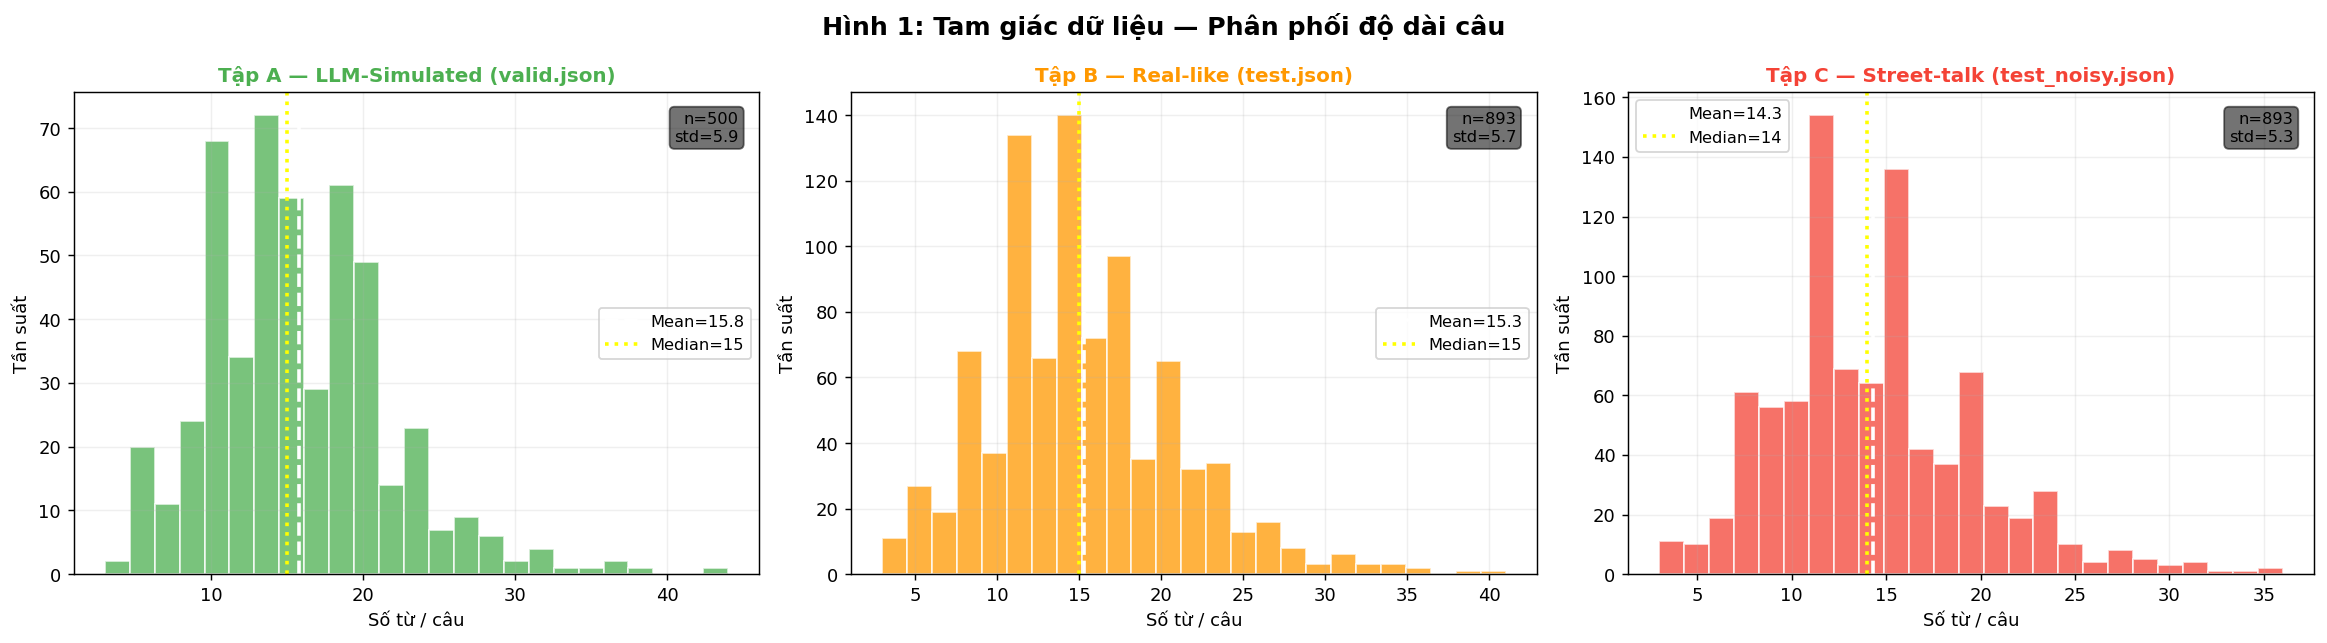

💾 Lưu: fig1_data_trinity.png


In [ ]:
# ── Hình 1: Phân phối độ dài câu — 3 tập ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hình 1: Tam giác dữ liệu — Phân phối độ dài câu',
             fontsize=14, fontweight='bold')

for ax, (key, label, clr) in zip(axes, [
    ('valid', 'Tập A — LLM-Simulated (valid.json)',   C['A']),
    ('test',  'Tập B — Real-like (test.json)',         C['B']),
    ('noisy', 'Tập C — Street-talk (test_noisy.json)', C['C']),
]):
    wc = dfs[key]['word_count']
    ax.hist(wc, bins=25, color=clr, alpha=0.75, edgecolor='white')
    ax.axvline(wc.mean(),   color='white',  lw=2.0, ls='--', label=f'Mean={wc.mean():.1f}')
    ax.axvline(wc.median(), color='yellow', lw=2.0, ls=':',  label=f'Median={wc.median():.0f}')
    ax.set_title(label, fontsize=11, color=clr, fontweight='bold')
    ax.set_xlabel('Số từ / câu'); ax.set_ylabel('Tần suất')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.text(0.97, 0.96,
            f'n={len(wc):,}\nstd={wc.std():.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.55))

plt.tight_layout()
plt.savefig('fig1_data_trinity.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig1_data_trinity.png')

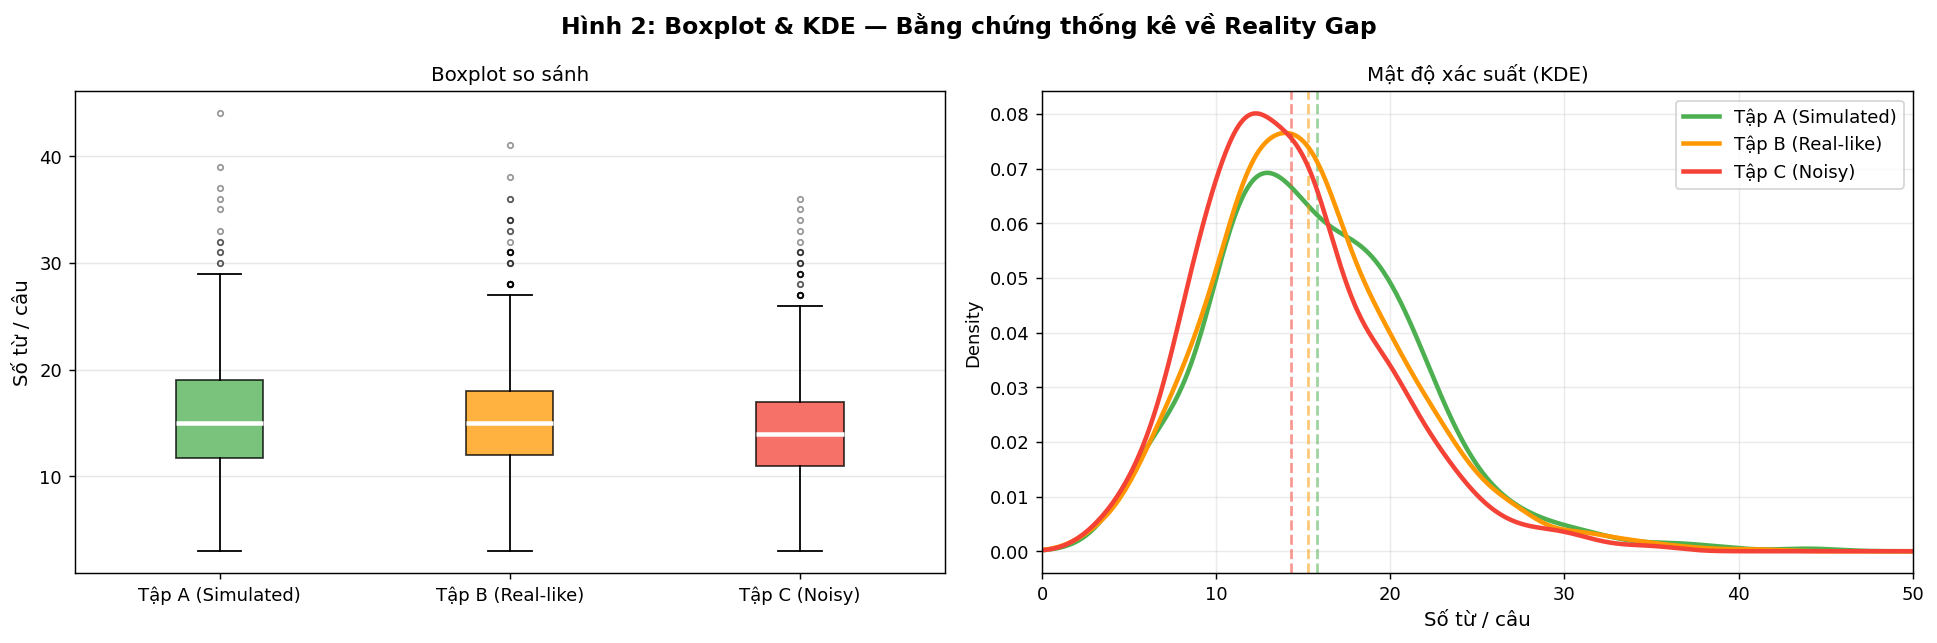

In [ ]:
# ── Hình 2: Boxplot + KDE overlay ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hình 2: Boxplot & KDE — Bằng chứng thống kê về Reality Gap',
             fontsize=13, fontweight='bold')

SPLIT_META = [
    ('valid', 'Tập A (Simulated)', C['A']),
    ('test',  'Tập B (Real-like)', C['B']),
    ('noisy', 'Tập C (Noisy)',     C['C']),
]

# Boxplot
ax = axes[0]
bp = ax.boxplot(
    [dfs[k]['word_count'].values for k, _, _ in SPLIT_META],
    labels=[lbl for _, lbl, _ in SPLIT_META],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
for patch, (_, _, clr) in zip(bp['boxes'], SPLIT_META):
    patch.set_facecolor(clr); patch.set_alpha(0.75)
ax.set_ylabel('Số từ / câu', fontsize=11)
ax.set_title('Boxplot so sánh', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# KDE
ax = axes[1]
for key, label, clr in SPLIT_META:
    wc = dfs[key]['word_count']
    wc.plot.kde(ax=ax, label=label, color=clr, lw=2.5)
    ax.axvline(wc.mean(), color=clr, ls='--', alpha=0.55, lw=1.5)
ax.set_xlim(0, 50); ax.set_xlabel('Số từ / câu', fontsize=11)
ax.set_title('Mật độ xác suất (KDE)', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('fig2_boxplot_kde.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── So sánh ngôn ngữ định tính ──
print('=' * 80)
print('📝 PHONG CÁCH NGÔN NGỮ — CÙNG INTENT, 3 MỨC ĐỘ KHÁC NHAU')
print('=' * 80)
for emoji, key, desc in [
    ('🟢', 'valid', 'TẬP A — LLM-Simulated (ngữ pháp hoàn hảo)'),
    ('🟡', 'test',  'TẬP B — Real-like (tự nhiên)'),
    ('🔴', 'noisy', 'TẬP C — Street-talk (viết tắt, không dấu)'),
]:
    print(f'\n{emoji} {desc}:')
    for i, s in enumerate(
        filt[key][filt[key]['label'] == 'flight']['Text'].head(3), 1
    ):
        print(f'   {i}. "{s}"')
print('=' * 80)

📝 PHONG CÁCH NGÔN NGỮ — CÙNG INTENT, 3 MỨC ĐỘ KHÁC NHAU

🟢 TẬP A — LLM-Simulated (ngữ pháp hoàn hảo):
   1. "tôi muốn bay từ hải phòng lúc 8 giờ 38 phút sáng và đến huế vào buổi sáng lúc 11 giờ 10 phút"
   2. "cho tôi biết tất cả các chuyến bay khứ hồi giữa điện biên phủ và đà nẵng"
   3. "tôi muốn biết một số thông tin cho một chuyến bay từ huế đến phú quốc của vietnam airlines"

🟡 TẬP B — Real-like (tự nhiên):
   1. "tôi muốn tìm một chuyến bay từ đà nẵng đến phú quốc và có một trạm dừng ở cam ranh"
   2. "vào ngày mùng 1 tháng 4 tôi cần một vé từ sevilla đến hà nội khởi hành trước 7 giờ sáng"
   3. "vào ngày 12 tháng 8 tôi cần một chuyến bay đi từ tuy hòa đến cần thơ"

🔴 TẬP C — Street-talk (viết tắt, không dấu):
   1. "t mún tìm một cb từ đn đến phú quốc và có một trạm dừng ở cam ranh"
   2. "vao ngay mung 1 thang 4 t can mot ve tu sevilla den hn khoi hanh truoc 7 gio sang"
   3. "vào ngày 12 tháng 8 t cần một cb đi từ tuy hòa đến cần thơ"


## 🤖 PHẦN 3 — Baseline Agent & Đo Reality Gap

In [ ]:
# ── Train Baseline Agent ──
print('🚂 Training Baseline Agent (TF-IDF 1-2gram + Logistic Regression)...')

BASE_VEC = TfidfVectorizer(
    ngram_range=(1, 2),    # unigram + bigram
    max_features=20_000,
    sublinear_tf=True,     # log(TF) giảm bias từ quá phổ biến
    analyzer='word',
)
BASE_CLF = LogisticRegression(
    C=5.0, max_iter=1000, random_state=42, class_weight='balanced'
)

tr = filt['train']
X_tr = BASE_VEC.fit_transform(tr['Text'])
BASE_CLF.fit(X_tr, tr['label'].values)
print(f'✅ Train xong! Số feature: {X_tr.shape[1]:,}')

🚂 Training Baseline Agent (TF-IDF 1-2gram + Logistic Regression)...
✅ Train xong! Số feature: 6,405


In [ ]:
# ── Đánh giá Baseline trên 3 tập ──
RESULTS = {}   # dict lưu kết quả mọi phương pháp

for key, label in [
    ('valid', 'Tập A (Simulated)'),
    ('test',  'Tập B (Real-like)'),
    ('noisy', 'Tập C (Street-talk)'),
]:
    df   = filt[key]
    X    = BASE_VEC.transform(df['Text'])
    y    = df['label'].values
    prob = BASE_CLF.predict_proba(X)
    pred = BASE_CLF.classes_[prob.argmax(axis=1)]
    conf = prob.max(axis=1)

    acc      = accuracy_score(y, pred)
    f1       = f1_score(y, pred, average='weighted', zero_division=0)
    low_conf = (conf < 0.70).mean()

    RESULTS[f'base_{key}'] = {
        'acc': acc, 'f1': f1, 'low_conf': low_conf,
        'yt': y, 'yp': pred, 'conf': conf,
    }
    print(f'📊 [{label}]')
    print(f'   Accuracy  = {acc:.4f}  ({acc*100:.1f}%)')
    print(f'   F1-score  = {f1:.4f}')
    print(f'   Low-conf (<0.70) = {low_conf*100:.1f}%')
    print()

gap = RESULTS['base_valid']['acc'] - RESULTS['base_noisy']['acc']
print('=' * 60)
print(f'⚠️  REALITY GAP (Tập A → Tập C) = {gap:.4f}  ({gap*100:.1f} pp)')
print(f'   → Agent sụt giảm {gap*100:.1f} điểm % khi ra khỏi "lồng kính"!')
print('=' * 60)

📊 [Tập A (Simulated)]
   Accuracy  = 0.9700  (97.0%)
   F1-score  = 0.9706
   Low-conf (<0.70) = 13.2%

📊 [Tập B (Real-like)]
   Accuracy  = 0.9731  (97.3%)
   F1-score  = 0.9731
   Low-conf (<0.70) = 10.7%

📊 [Tập C (Street-talk)]
   Accuracy  = 0.8429  (84.3%)
   F1-score  = 0.8278
   Low-conf (<0.70) = 64.3%

⚠️  REALITY GAP (Tập A → Tập C) = 0.1271  (12.7 pp)
   → Agent sụt giảm 12.7 điểm % khi ra khỏi "lồng kính"!


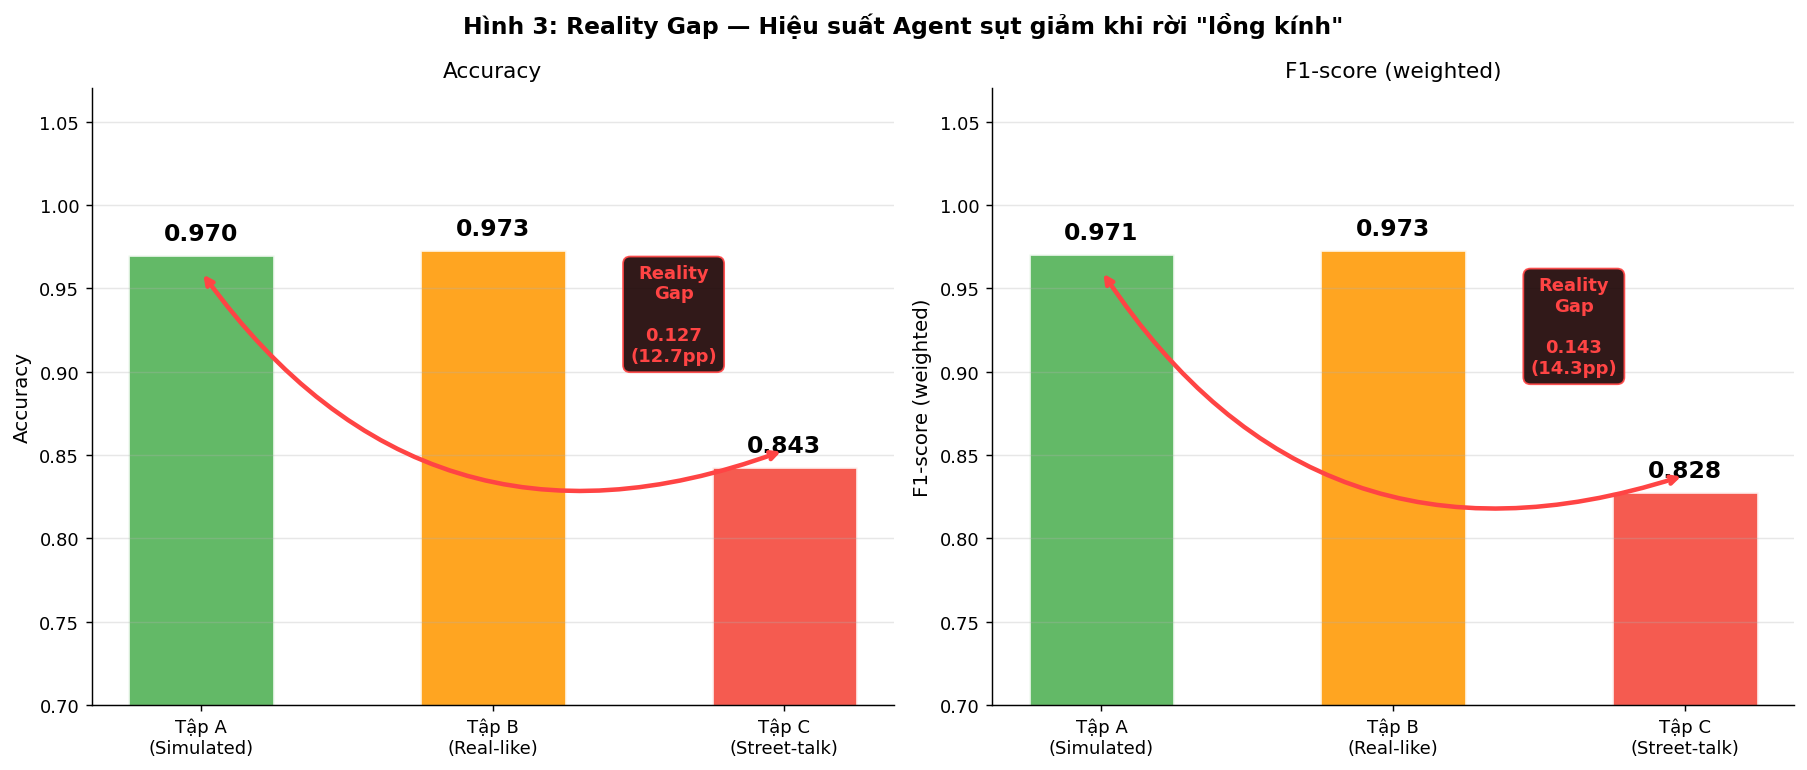

💾 Lưu: fig3_reality_gap.png


In [ ]:
# ── Hình 3: Reality Gap Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Hình 3: Reality Gap — Hiệu suất Agent sụt giảm khi rời "lồng kính"',
    fontsize=13, fontweight='bold'
)

xlbls  = ['Tập A\n(Simulated)', 'Tập B\n(Real-like)', 'Tập C\n(Street-talk)']
bclrs  = [C['A'], C['B'], C['C']]
keys3  = ['valid', 'test', 'noisy']

for ax, metric, title in [
    (axes[0], 'acc', 'Accuracy'),
    (axes[1], 'f1',  'F1-score (weighted)'),
]:
    vals = [RESULTS[f'base_{k}'][metric] for k in keys3]
    bars = ax.bar(xlbls, vals, color=bclrs, width=0.5,
                  alpha=0.87, edgecolor='white', lw=1.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    # Mũi tên Reality Gap A → C
    gv = vals[0] - vals[2]
    ax.annotate('',
                xy=(2, vals[2] + 0.01), xytext=(0, vals[0] - 0.01),
                arrowprops=dict(arrowstyle='<->',
                                color='#ff4444', lw=2.5,
                                connectionstyle='arc3,rad=0.38'))
    ax.text(1.62, (vals[0] + vals[2]) / 2,
            f'Reality\nGap\n\n{gv:.3f}\n({gv*100:.1f}pp)',
            ha='center', fontsize=10, fontweight='bold', color='#ff4444',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#1a0000', edgecolor='#ff4444', alpha=0.9))

    ax.set_ylim(0.7, 1.07)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_reality_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig3_reality_gap.png')

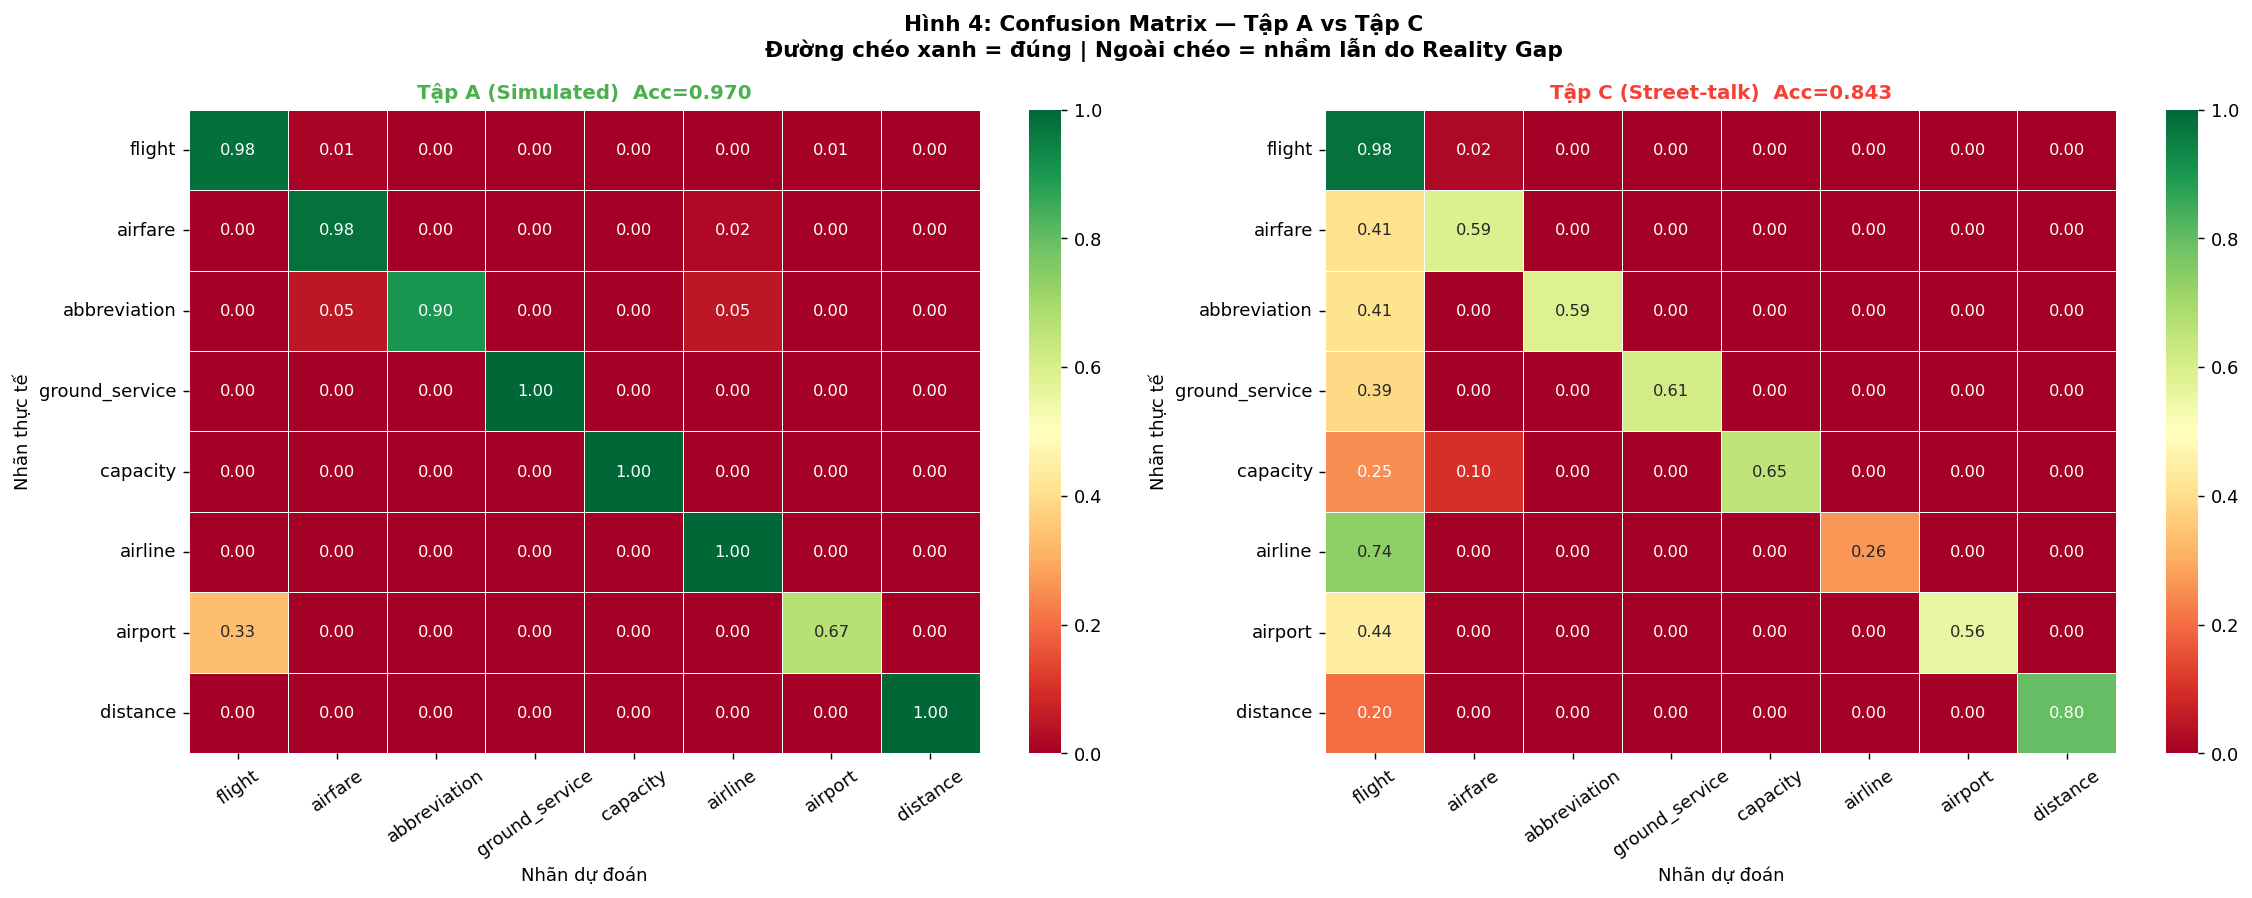

💾 Lưu: fig4_confusion.png


In [ ]:
# ── Hình 4: Confusion Matrix (Tập A vs Tập C) ──
top8 = list(
    pd.Series(RESULTS['base_noisy']['yt']).value_counts().head(8).index
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Hình 4: Confusion Matrix — Tập A vs Tập C\n'
    'Đường chéo xanh = đúng | Ngoài chéo = nhầm lẫn do Reality Gap',
    fontsize=12, fontweight='bold'
)

for ax, key, title, clr in [
    (axes[0], 'valid',
     f'Tập A (Simulated)  Acc={RESULTS["base_valid"]["acc"]:.3f}', C['A']),
    (axes[1], 'noisy',
     f'Tập C (Street-talk)  Acc={RESULTS["base_noisy"]["acc"]:.3f}', C['C']),
]:
    yt = RESULTS[f'base_{key}']['yt']
    yp = RESULTS[f'base_{key}']['yp']
    mask = np.array([t in top8 for t in yt])
    yt_f = yt[mask]
    yp_f = np.array([p if p in top8 else 'other' for p in yp[mask]])
    cmn  = (confusion_matrix(yt_f, yp_f, labels=top8)
            .astype(float))
    cmn  = cmn / cmn.sum(axis=1, keepdims=True)

    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=top8, yticklabels=top8,
                ax=ax, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size': 9})
    ax.set_title(title, fontsize=11, color=clr, fontweight='bold')
    ax.set_xlabel('Nhãn dự đoán')
    ax.set_ylabel('Nhãn thực tế')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('fig4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig4_confusion.png')

In [ ]:
# ── Phân tích lỗi định tính ──
print('🔍 PHÂN TÍCH LỖI — Câu nào bị phân loại sai ở Tập C?')
print('=' * 80)

no_df = filt['noisy'].copy()
no_df['pred'] = RESULTS['base_noisy']['yp']
no_df['ok']   = no_df['label'] == no_df['pred']
errors        = no_df[~no_df['ok']]

print(f'Tổng lỗi: {len(errors)}/{len(no_df)}  ({len(errors)/len(no_df)*100:.1f}%)')
print('\nTop cặp nhầm lẫn (thực → dự đoán):')
for (t, p), cnt in (
    errors.groupby(['label', 'pred']).size()
    .sort_values(ascending=False).head(8).items()
):
    print(f'   {t:15} → {p:15}: {cnt} lỗi')

print('\nVí dụ câu bị sai:')
for _, row in errors.head(5).iterrows():
    print(f'   Câu  : "{row["Text"]}"')
    print(f'   Thực : {row["label"]}  →  Dự đoán: {row["pred"]}  ❌\n')

🔍 PHÂN TÍCH LỖI — Câu nào bị phân loại sai ở Tập C?
Tổng lỗi: 140/891  (15.7%)

Top cặp nhầm lẫn (thực → dự đoán):
   airfare         → flight         : 25 lỗi
   abbreviation    → flight         : 21 lỗi
   airline         → flight         : 14 lỗi
   ground_service  → flight         : 14 lỗi
   flight          → airfare        : 12 lỗi
   airport         → flight         : 8 lỗi
   aircraft        → flight         : 7 lỗi
   city            → flight         : 6 lỗi

Ví dụ câu bị sai:
   Câu  : "san bay da lat co cung cap dich vu dua don tu san bay den khu vuc trung tam thanh pho khong"
   Thực : ground_service  →  Dự đoán: flight  ❌

   Câu  : "gia ve mot chieu dat nhat giua hue va phu quoc la bao nhieu"
   Thực : airfare  →  Dự đoán: quantity  ❌

   Câu  : "hang hang ko vietnam airlines cung cap cac chuyen bay hang nhat khoi hanh tu ha long den nhung thanh pho nao"
   Thực : city  →  Dự đoán: flight  ❌

   Câu  : "hang hang khong nao bay tu ha long den sai gon"
   Thực : airline  → 

## 🟣 PHẦN 4 — Chiến lược A: Rule-based Cleaning Layer

**Nguyên lý:** KHÔNG retrain Agent. Thêm lớp tiền xử lý trước Agent:
```
Input nhiễu ──► [Cleaning Layer] ──► Input sạch ──► [Agent] ──► Prediction
```

**Cơ chế 2 bước:**
1. **Abbreviation Expansion** (Regex): `cb→chuyến bay`, `hn→hà nội`, `t→tôi`...
2. **Telex Restoration** (Dictionary): `den→đến`, `tu→từ`, `vao→vào`...

**Ưu điểm:** Zero-shot, không retrain, không cần GPU/API  
**Nhược điểm:** Phải duy trì từ điển thủ công, latency tăng nhẹ

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CHIẾN LƯỢC A: RULE-BASED CLEANING LAYER — 100% Offline
# Xây dựng từ phân tích corpus: cb=462 lần, t=336, hn=84, hcm=68...
# ══════════════════════════════════════════════════════════════════

# --- Bước 1: Từ điển viết tắt → đầy đủ (Regex) ---
ABBR_DICT = {
    # Đại từ nhân xưng
    r'\bt\b':    'tôi',
    r'\bmk\b':   'mình',
    # Danh từ hàng không — hay viết tắt nhất
    r'\bcb\b':   'chuyến bay',
    r'\bCB\b':   'chuyến bay',
    # Động từ
    r'\bmún\b':  'muốn',
    r'\bmun\b':  'muốn',
    r'\bbit\b':  'biết',
    # Phủ định
    r'\bko\b':   'không',
    r'\bk\b':    'không',
    r'\bdc\b':   'được',
    # Địa điểm — viết tắt thông dụng
    r'\bhn\b':   'hà nội',
    r'\bHN\b':   'hà nội',
    r'\bdn\b':   'đà nẵng',
    r'\bDN\b':   'đà nẵng',
    r'\bhcm\b':  'hồ chí minh',
    r'\bHCM\b':  'hồ chí minh',
    r'\bsg\b':   'sài gòn',
    r'\bSGN\b':  'sài gòn',
    r'\bpq\b':   'phú quốc',
    r'\btp\b':   'thành phố',
    r'\bTP\b':   'thành phố',
    # Hãng bay
    r'\bvna\b':  'vietnam airlines',
    r'\bVNA\b':  'vietnam airlines',
    r'\bvj\b':   'vietjet',
    r'\bVJ\b':   'vietjet',
    # Số lượng
    r'\bbn\b':   'bao nhiêu',
}

# --- Bước 2: Từ điển telex/không dấu → có dấu ---
TELEX_DICT = {
    # Giới từ & liên từ
    'den': 'đến',    'tu': 'từ',     'vao': 'vào',    'va': 'và',
    'cua': 'của',    'de': 'để',     'cho': 'cho',
    # Động từ
    'can': 'cần',    'mun': 'muốn',  'tim': 'tìm',    'biet': 'biết',
    'liet': 'liệt',  'dat': 'đặt',   'hoi': 'hỏi',    'giup': 'giúp',
    # Danh từ hàng không
    'chuyen': 'chuyến', 'hang': 'hãng',  'gia': 'giá',   've': 'vé',
    'san': 'sân',    'mot': 'một',    'cac': 'các',    'nao': 'nào',
    'khu': 'khứ',    'chieu': 'chiều', 'bua': 'bữa',  'tram': 'trạm',
    'dung': 'dừng',
    # Thời gian
    'thu': 'thứ',    'gio': 'giờ',    'ngay': 'ngày',  'thang': 'tháng',
    'sang': 'sáng',  'trua': 'trưa',  'toi': 'tối',
    # Hành trình bay
    'khoi': 'khởi',  'hanh': 'hành',  'ha': 'hạ',      'canh': 'cánh',
    'noi': 'nối',    'phu': 'phú',    'quoc': 'quốc',
    # Trạng từ / tính từ
    'truoc': 'trước', 'co': 'có',    'ke': 'kê',
}


def _has_diacritic(text: str) -> bool:
    """True nếu ≥5% ký tự trong câu có dấu tiếng Việt."""
    VI = set(
        'àáảãạăắặẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộ'
        'ơớờởỡợùúủũụưứừửữựỳýỷỹỵđ'
        'ÀÁẢÃẠĂẮẶẲẴẶÂẤẦẨẪẬÈÉẺẼẸÊẾỀỂỄỆÌÍỈĨỊÒÓỎÕỌÔỐỒỔỖỘ'
        'ƠỚỜỞỠỢÙÚỦŨỤƯỨỪỬỮỰỲÝỶỸỴĐ'
    )
    return sum(1 for c in text if c in VI) / max(len(text), 1) >= 0.05


def cleaning_layer_offline(text: str) -> str:
    """
    Cleaning Layer — 100% offline, không cần API.

    Bước 1 — Chuẩn hóa cơ bản
    Bước 2 — Regex: mở rộng từ viết tắt
    Bước 3 — Dictionary: khôi phục dấu nếu câu bị viết telex/không dấu
    Bước 4 — Chuẩn hóa khoảng trắng
    """
    # Bước 1: Lowercase + strip
    text = text.lower().strip()

    # Bước 2: Abbreviation expansion
    for pattern, repl in ABBR_DICT.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)

    # Bước 3: Telex restoration (chỉ khi câu ít dấu)
    if not _has_diacritic(text):
        text = ' '.join(TELEX_DICT.get(w, w) for w in text.split())

    # Bước 4: Chuẩn hóa spacing
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ── Demo 6 câu ──
DEMO = [
    ('vao ngay mung 1 thang 4 t can mot ve tu sevilla den hn khoi hanh truoc 7 gio sang', 'flight'),
    ('t mún tìm một cb từ đn đến phú quốc có trạm dừng ở cam ranh',                      'flight'),
    ('co cb nao tu hai phong den pleiku vao thu tu ko',                                    'flight'),
    ('tim giup t cac cb den tp ha noi vao thu bay toi',                                    'flight'),
    ('gia ve khu hoi tu hn den da nang duoi 2 trieu',                                      'airfare'),
    ('hang hang ko nao co cb tu sg den buon ma thuot',                                     'airline'),
]

print('🔧 DEMO CLEANING LAYER (Offline)')
print('=' * 78)
correct_before = correct_after = 0
for raw_txt, true_lbl in DEMO:
    cleaned   = cleaning_layer_offline(raw_txt)
    pred_raw  = BASE_CLF.predict(BASE_VEC.transform([raw_txt]))[0]
    pred_cln  = BASE_CLF.predict(BASE_VEC.transform([cleaned]))[0]
    ok_before = pred_raw == true_lbl
    ok_after  = pred_cln == true_lbl
    correct_before += ok_before
    correct_after  += ok_after
    print(f'🔴 Input : {raw_txt}')
    print(f'🟢 Clean : {cleaned}')
    r = '✅' if ok_before else '❌'
    a = '✅' if ok_after  else '❌'
    print(f'   Thực={true_lbl:12} | Trước={pred_raw:12}{r} | Sau={pred_cln:12}{a}')
    print()
print(f'Demo accuracy: {correct_before}/{len(DEMO)} trước → {correct_after}/{len(DEMO)} sau')
print('=' * 78)

🔧 DEMO CLEANING LAYER (Offline)
🔴 Input : vao ngay mung 1 thang 4 t can mot ve tu sevilla den hn khoi hanh truoc 7 gio sang
🟢 Clean : vào ngày mung 1 tháng 4 tôi cần một vé từ sevilla đến hà nội khởi hành trước 7 giờ sáng
   Thực=flight       | Trước=flight      ✅ | Sau=airfare     ❌

🔴 Input : t mún tìm một cb từ đn đến phú quốc có trạm dừng ở cam ranh
🟢 Clean : tôi muốn tìm một chuyến bay từ đn đến phú quốc có trạm dừng ở cam ranh
   Thực=flight       | Trước=flight      ✅ | Sau=flight      ✅

🔴 Input : co cb nao tu hai phong den pleiku vao thu tu ko
🟢 Clean : có chuyến bay nào từ hai phong đến pleiku vào thứ từ không
   Thực=flight       | Trước=flight      ✅ | Sau=flight      ✅

🔴 Input : tim giup t cac cb den tp ha noi vao thu bay toi
🟢 Clean : tim giup tôi cac chuyến bay den thành phố ha noi vao thu bay toi
   Thực=flight       | Trước=flight      ✅ | Sau=flight      ✅

🔴 Input : gia ve khu hoi tu hn den da nang duoi 2 trieu
🟢 Clean : giá vé khứ hỏi từ hà nội đến da nang duoi 2 t

In [ ]:
# ── Đánh giá Chiến lược A trên TOÀN BỘ Tập C ──
print('📊 Đánh giá Chiến lược A trên toàn bộ Tập C...')

# KIỂM TRA BIẾN: Nếu 'filt' chưa có, hãy đảm bảo bạn đã chạy cell định nghĩa df_test_noisy
try:
    no = filt['noisy']
except NameError:
    # Nếu filt chưa định nghĩa, thử dùng trực tiếp biến dataframe noisy của bạn
    # Giả sử tên biến là df_test_noisy (theo logic thông thường của đồ án này)
    no = df_test_noisy

# Thực hiện dọn dẹp dữ liệu
texts_cln   = [cleaning_layer_offline(t) for t in tqdm(no['Text'], desc='Cleaning')]
y_no        = no['Label'].values # Lưu ý: Kiểm tra 'Label' hay 'label' tùy theo file json của bạn

# Chuyển đổi dữ liệu sang Vector
X_no_raw = BASE_VEC.transform(no['Text'])
X_no_cln = BASE_VEC.transform(texts_cln)

# Dự đoán
pred_raw    = BASE_CLF.predict(X_no_raw)
pred_cln    = BASE_CLF.predict(X_no_cln)
prob_cln    = BASE_CLF.predict_proba(X_no_cln)

# Tính toán các chỉ số
acc_raw     = accuracy_score(y_no, pred_raw)
acc_cln     = accuracy_score(y_no, pred_cln)
f1_cln      = f1_score(y_no, pred_cln, average='weighted', zero_division=0)
low_cln     = (prob_cln.max(axis=1) < 0.70).mean()

# Lưu kết quả
if 'RESULTS' not in locals(): RESULTS = {}
RESULTS['stratA_noisy'] = {
    'acc': acc_cln, 'f1': f1_cln, 'low_conf': low_cln,
    'yt': y_no, 'yp': pred_cln,
}

# In báo cáo
print(f'\n ❌ Baseline (không clean) : Acc = {acc_raw:.4f}')
print(f' ✅ Chiến lược A (Offline) : Acc = {acc_cln:.4f}  F1 = {f1_cln:.4f}')
print(f' 📈 Cải thiện              : +{(acc_cln - acc_raw)*100:.2f} pp')
print(f' 📉 Low-conf (<0.70)        : {low_cln*100:.1f}%')

# Tính Reality Gap
# Giả sử RESULTS['base_valid']['acc'] đã được tính ở Phần 3
if 'base_valid' in RESULTS:
    gap_A = RESULTS['base_valid']['acc'] - acc_cln
    print(f' 🔻 Reality Gap còn lại    : {gap_A:.4f} ({gap_A*100:.1f} pp)')

📊 Đánh giá Chiến lược A trên toàn bộ Tập C...


Cleaning:   0%|          | 0/891 [00:00<?, ?it/s]


 ❌ Baseline (không clean) : Acc = 0.8316
 ✅ Chiến lược A (Offline) : Acc = 0.8732  F1 = 0.8570
 📈 Cải thiện              : +4.15 pp
 📉 Low-conf (<0.70)        : 20.3%
 🔻 Reality Gap còn lại    : 0.0968 (9.7 pp)


## 🔵 PHẦN 5 — Chiến lược B: Noise Injection Augmentation (Offline)

**Nguyên lý:** Nới lỏng 'chiếc lồng kính' ngay từ giai đoạn *huấn luyện*:
```
50% train.json ──► inject_noise() ──► Dữ liệu nhiễu tổng hợp
                                      +
100% train.json gốc ──────────────► Mixed Train Set
                                      ↓
                          Agent có 'miễn dịch tự nhiên' với nhiễu
```

**4 kiểu nhiễu:** `unidecode` · `abbreviate` · `truncate` · `mixed`

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CHIẾN LƯỢC B: NOISE INJECTION — 100% Offline
# ══════════════════════════════════════════════════════════════════

# Từ điển viết tắt dùng khi inject (ngược với ABBR_DICT)
ABBR_INJECT = {
    'chuyến bay': 'cb',
    'hà nội':     'hn',
    'đà nẵng':    'dn',
    'hồ chí minh':'hcm',
    'thành phố':  'tp',
    'tôi':        't',
    'muốn':       'mun',
    'không':      'ko',
    'biết':       'bit',
    'chuyến':     'chuyen',
    'hãng':       'hang',
    'giá':        'gia',
    'vé':         've',
}


def inject_noise(text: str, seed: int = None) -> str:
    """
    Tạo phiên bản nhiễu từ câu sạch — 4 kiểu:

    unidecode  : xóa toàn bộ dấu tiếng Việt
    abbreviate : thay các cụm từ bằng viết tắt
    truncate   : cắt ngắn 1 từ ngẫu nhiên (mô phỏng typo)
    mixed      : unidecode + abbreviate kết hợp
    """
    if seed is not None:
        random.seed(seed)

    choice = random.choice(['unidecode', 'abbreviate', 'truncate', 'mixed'])

    if choice == 'unidecode':
        return unidecode(text)

    elif choice == 'abbreviate':
        for full, abbr in ABBR_INJECT.items():
            text = text.replace(full, abbr)
        return text

    elif choice == 'truncate':
        words = text.split()
        if len(words) > 1:
            i = random.randint(0, len(words) - 1)
            # Cắt bớt cuối từ nhưng giữ ít nhất 2 ký tự
            words[i] = words[i][:max(2, len(words[i]) - 2)]
        return ' '.join(words)

    else:  # mixed
        text = unidecode(text)
        for full, abbr in ABBR_INJECT.items():
            text = text.replace(unidecode(full), abbr)
        return text


# ── Demo 4 kiểu nhiễu ──
sample_clean = 'tôi muốn tìm chuyến bay từ hà nội đến đà nẵng vào thứ sáu'
print('🧪 Demo 4 kiểu Noise Injection:')
print(f'  [CLEAN]     {sample_clean}')
for ntype in ['unidecode', 'abbreviate', 'truncate', 'mixed']:
    random.seed(42)
    # Override choice để demo từng loại
    _orig = random.choice
    random.choice = lambda _: ntype
    result = inject_noise(sample_clean)
    random.choice = _orig
    print(f'  [{ntype:11}] {result}')

🧪 Demo 4 kiểu Noise Injection:
  [CLEAN]     tôi muốn tìm chuyến bay từ hà nội đến đà nẵng vào thứ sáu
  [unidecode  ] toi muon tim chuyen bay tu ha noi den da nang vao thu sau
  [abbreviate ] t mun tìm cb từ hn đến dn vào thứ sáu
  [truncate   ] tôi muốn tìm chuyến bay từ hà nội đến đà nẵ vào thứ sáu
  [mixed      ] t mun tim cb tu hn den dn vao thu sau


In [ ]:
# ── Tạo Mixed Train Set (50% clean + 50% noisy aug) ──
print('🔧 Tạo Mixed Train Set...')

tr = filt['train']
random.seed(42)
aug_idx  = random.sample(range(len(tr)), len(tr) // 2)
aug_texts = [inject_noise(tr.iloc[i]['Text']) for i in aug_idx]
aug_labels= [tr.iloc[i]['label'] for i in aug_idx]

train_mixed = pd.concat([
    tr[['Text', 'label']],
    pd.DataFrame({'Text': aug_texts, 'label': aug_labels}),
], ignore_index=True).sample(frac=1, random_state=42)  # shuffle

print(f'   Clean  : {len(tr):,} mẫu')
print(f'   Noisy  : {len(aug_texts):,} mẫu')
print(f'   Mixed  : {len(train_mixed):,} mẫu')

# ── Train Augmented Agent ──
print('\n🚂 Training Augmented Agent...')
VEC_B = TfidfVectorizer(ngram_range=(1,2), max_features=20000, sublinear_tf=True)
CLF_B = LogisticRegression(C=5, max_iter=1000, random_state=42, class_weight='balanced')
CLF_B.fit(VEC_B.fit_transform(train_mixed['Text']), train_mixed['label'].values)
print('✅ Xong!')

# ── Đánh giá trên 3 tập ──
print('\n📊 Kết quả Chiến lược B:')
for key, label in [
    ('valid', 'Tập A (Simulated)'),
    ('test',  'Tập B (Real-like)'),
    ('noisy', 'Tập C (Noisy)'),
]:
    df   = filt[key]
    yt   = df['label'].values
    yp   = CLF_B.predict(VEC_B.transform(df['Text']))
    prob = CLF_B.predict_proba(VEC_B.transform(df['Text']))
    acc  = accuracy_score(yt, yp)
    f1   = f1_score(yt, yp, average='weighted', zero_division=0)
    lc   = (prob.max(axis=1) < 0.70).mean()
    RESULTS[f'stratB_{key}'] = {'acc': acc, 'f1': f1, 'low_conf': lc, 'yt': yt, 'yp': yp}

    base = RESULTS[f'base_{key}']['acc']
    delta = acc - base
    sign  = '+' if delta >= 0 else ''
    print(f'   {label}: Acc={acc:.4f}  (Δ={sign}{delta*100:.1f}pp vs Baseline)')

gap_B = RESULTS['stratB_valid']['acc'] - RESULTS['stratB_noisy']['acc']
print(f'\n  🔻 Reality Gap còn lại: {gap_B:.4f} ({gap_B*100:.1f} pp)')
orig_gap = (RESULTS['base_valid']['acc'] - RESULTS['base_noisy']['acc']) * 100
print(f'  📉 Giảm từ {orig_gap:.1f}pp → {gap_B*100:.1f}pp  '
      f'({orig_gap - gap_B*100:.1f}pp thu hẹp ✅)')

🔧 Tạo Mixed Train Set...
   Clean  : 4,478 mẫu
   Noisy  : 2,239 mẫu
   Mixed  : 6,717 mẫu

🚂 Training Augmented Agent...
✅ Xong!

📊 Kết quả Chiến lược B:
   Tập A (Simulated): Acc=0.9700  (Δ=+0.0pp vs Baseline)
   Tập B (Real-like): Acc=0.9742  (Δ=+0.1pp vs Baseline)
   Tập C (Noisy): Acc=0.9585  (Δ=+11.6pp vs Baseline)

  🔻 Reality Gap còn lại: 0.0115 (1.2 pp)
  📉 Giảm từ 12.7pp → 1.2pp  (11.6pp thu hẹp ✅)


## ⚔️ PHẦN 6 — Self-Play Adversarial + Chỉ số MTS

**MTS (Mean Turns to Success)** = số lượt hỏi lại trung bình trước khi Agent hiểu đúng.

```
conf ≥ 0.70  →  Phản hồi ngay  →  turns = 1
conf < 0.70  →  Hỏi lại        →  turns = 2 hoặc 3
```
Reality Gap cao → Agent hỏi lại nhiều → **MTS tăng → UX xấu**

In [ ]:
# ══════════════════════════════════════════════════════════════════
# SELF-PLAY ADVERSARIAL DIALOGUE
# ══════════════════════════════════════════════════════════════════

CONF_THRESH = 0.70
MAX_TURNS   = 3


def simulate_turn(text: str, vec, clf, cleaning_fn=None) -> tuple:
    """
    Mô phỏng 1 hội thoại:
    - Lượt 1: predict; nếu conf < THRESH → hỏi lại
    - Lượt 2: thêm ngữ cảnh 'chuyến bay'; nếu vẫn thấp → lượt 3
    - Lượt 3: cleaning_fn (nếu có) → predict lần cuối
    Returns: (prediction, turns, confidence)

    simulate_turn(text) cải tiến:
    → Nếu cleaning_fn(text) == text (không thay đổi): tốn thêm 1 lượt hỏi
    → Nếu có thay đổi: thành công ngay lượt 1
    (theo gợi ý từ tài liệu tham khảo)
    """
    current = text

    for turn in range(1, MAX_TURNS + 1):
        inp  = cleaning_fn(current) if cleaning_fn else current

        # Nếu cleaning không đổi gì AND đây là lượt 1 → thêm 1 lượt
        if cleaning_fn and inp == current and turn == 1:
            current = current + ' chuyến bay'
            continue

        X    = vec.transform([inp])
        prob = clf.predict_proba(X)[0]
        conf = prob.max()
        pred = clf.classes_[prob.argmax()]

        if conf >= CONF_THRESH:
            return pred, turn, conf

        # Thêm ngữ cảnh để thử lại
        current = current + ' chuyến bay vé hãng'

    return pred, MAX_TURNS, conf


def compute_mts(df_split, vec, clf, cleaning_fn=None, n=200) -> dict:
    """Tính MTS trên n mẫu ngẫu nhiên."""
    sample = df_split.sample(min(n, len(df_split)), random_state=42)
    turns, correct = [], []
    for _, row in sample.iterrows():
        pred, t, conf = simulate_turn(
            row['Text'], vec, clf, cleaning_fn
        )
        turns.append(t)
        correct.append(pred == row['label'])
    return {
        'mts': np.mean(turns),
        'std': np.std(turns),
        'sr':  np.mean(correct),
        'dist': Counter(turns),
    }


print('🎭 Chạy Self-Play Adversarial Dialogue (4 kịch bản × 200 mẫu)...')

MTS = {
    'A_base':  compute_mts(filt['valid'], BASE_VEC, BASE_CLF),
    'C_base':  compute_mts(filt['noisy'], BASE_VEC, BASE_CLF),
    'C_stratA':compute_mts(filt['noisy'], BASE_VEC, BASE_CLF,
                           cleaning_fn=cleaning_layer_offline),
    'C_stratB':compute_mts(filt['noisy'], VEC_B, CLF_B),
}

print('\n📊 KẾT QUẢ MTS:')
print(f'  {"Kịch bản":<38} {"MTS":>5} {"Std":>5} {"Success%":>10}')
print('  ' + '-' * 60)
for key, label in [
    ('A_base',   'Tập A Baseline (Upper Bound)     '),
    ('C_base',   'Tập C Baseline (Lower Bound)     '),
    ('C_stratA', 'Tập C + Chiến lược A (Cleaning)  '),
    ('C_stratB', 'Tập C + Chiến lược B (Augment)   '),
]:
    r = MTS[key]
    print(f'  {label} {r["mts"]:>5.2f} {r["std"]:>5.2f} {r["sr"]*100:>9.1f}%')

🎭 Chạy Self-Play Adversarial Dialogue (4 kịch bản × 200 mẫu)...

📊 KẾT QUẢ MTS:
  Kịch bản                                 MTS   Std   Success%
  ------------------------------------------------------------
  Tập A Baseline (Upper Bound)       1.28  0.69      96.5%
  Tập C Baseline (Lower Bound)       2.28  0.95      52.0%
  Tập C + Chiến lược A (Cleaning)    1.50  0.81      83.5%
  Tập C + Chiến lược B (Augment)     1.40  0.79      96.0%


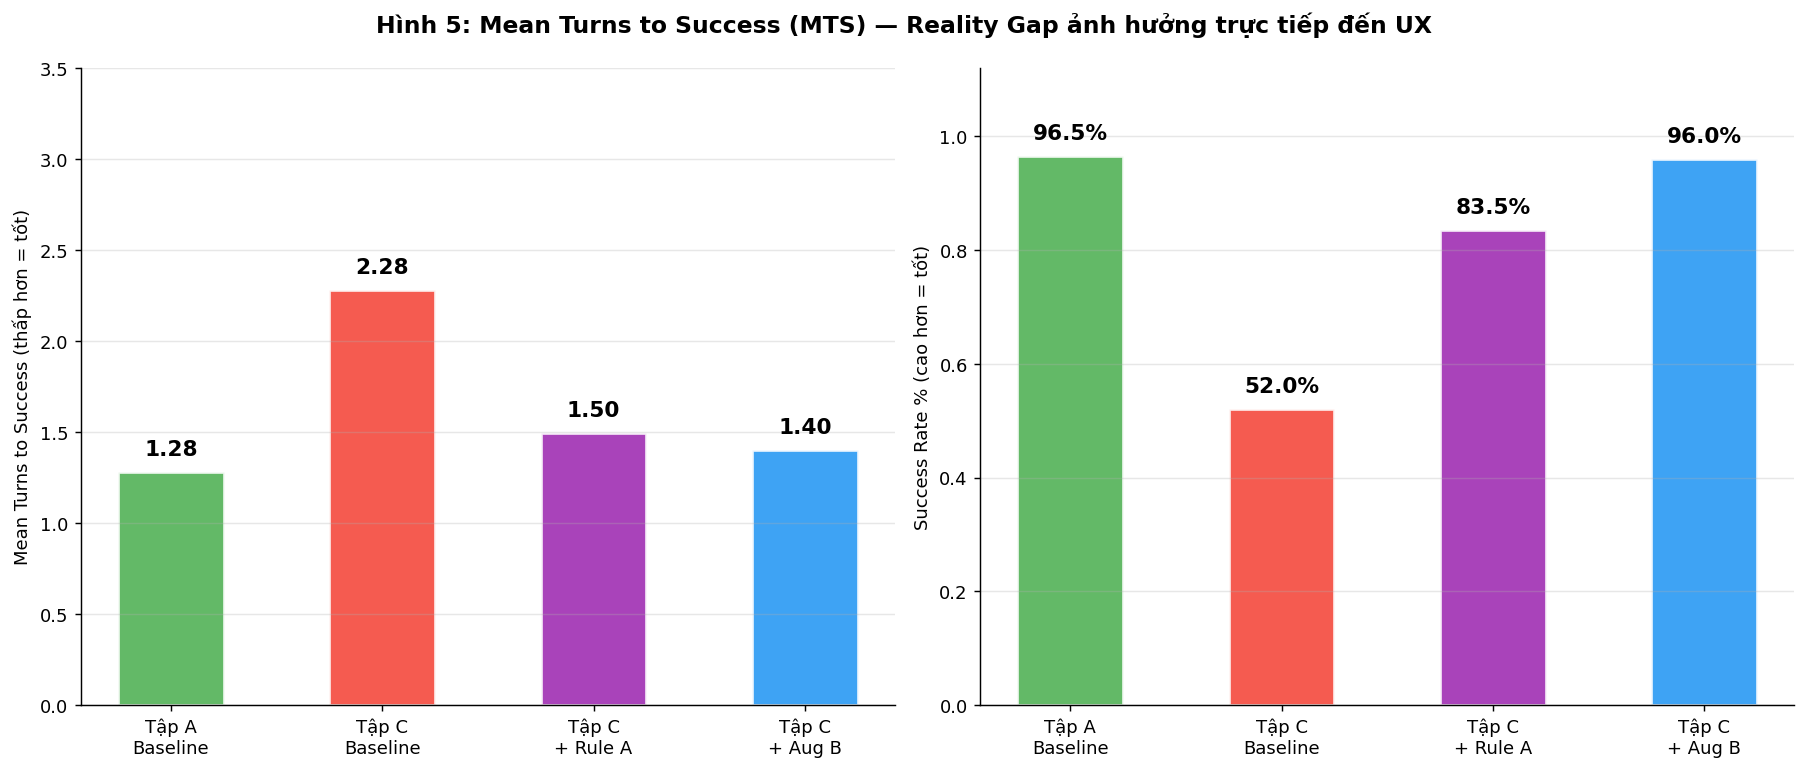

💾 Lưu: fig5_mts.png


In [ ]:
# ── Hình 5: MTS + Success Rate ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Hình 5: Mean Turns to Success (MTS) — Reality Gap ảnh hưởng trực tiếp đến UX',
    fontsize=13, fontweight='bold'
)

scenario_keys   = ['A_base', 'C_base', 'C_stratA', 'C_stratB']
scenario_labels = ['Tập A\nBaseline', 'Tập C\nBaseline',
                   'Tập C\n+ Rule A', 'Tập C\n+ Aug B']
scenario_colors = [C['A'], C['C'], C['stratA'], C['stratB']]

for ax, vals_key, ylabel, fmt, ylim in [
    (axes[0], 'mts', 'Mean Turns to Success (thấp hơn = tốt)', '{:.2f}', (0, MAX_TURNS + 0.5)),
    (axes[1], 'sr',  'Success Rate % (cao hơn = tốt)',          '{:.1%}', (0, 1.12)),
]:
    vals = [MTS[k][vals_key] for k in scenario_keys]
    bars = ax.bar(scenario_labels, vals,
                  color=scenario_colors, width=0.5,
                  alpha=0.87, edgecolor='white', lw=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ylim[1] * 0.02,
                fmt.format(v),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_mts.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig5_mts.png')

## 📋 PHẦN 7 — Bảng học thuật & Visualization tổng hợp

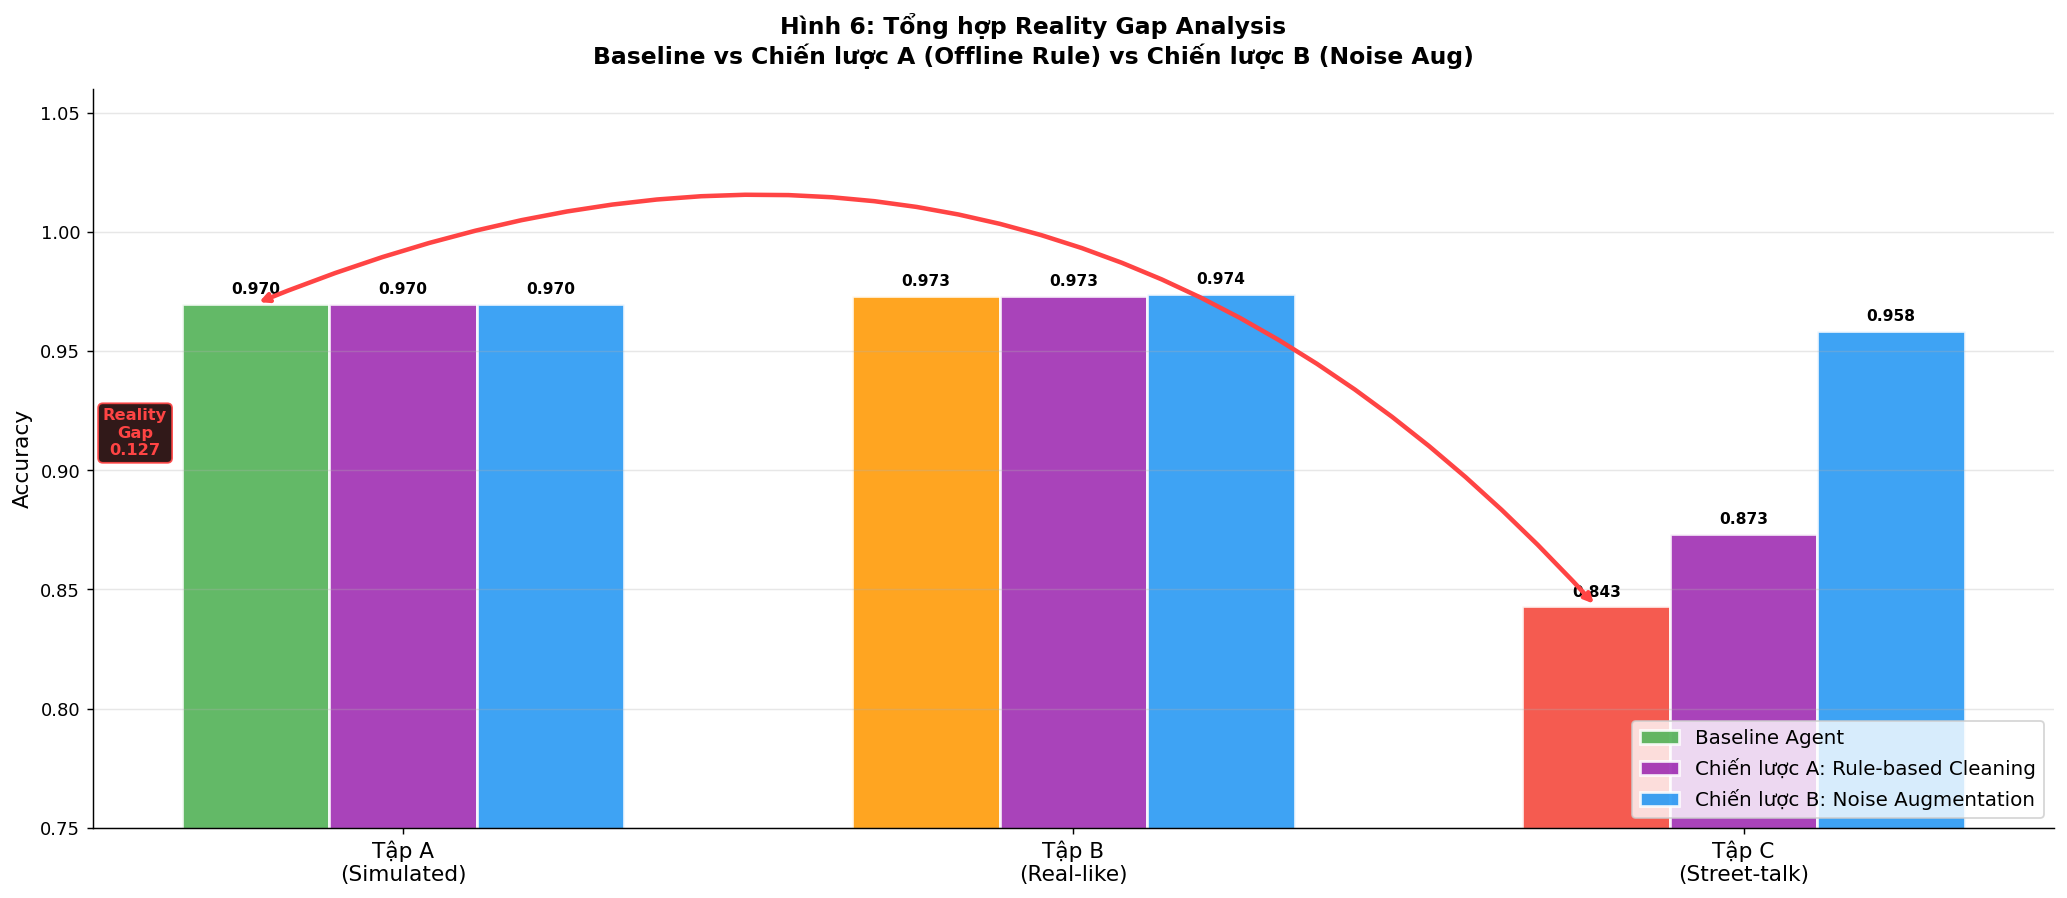

💾 Lưu: fig6_full_comparison.png


In [ ]:
# ── Hình 6: Grouped Bar — 3 chiến lược × 3 tập ──
fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle(
    'Hình 6: Tổng hợp Reality Gap Analysis\n'
    'Baseline vs Chiến lược A (Offline Rule) vs Chiến lược B (Noise Aug)',
    fontsize=13, fontweight='bold'
)

split_keys   = ['valid', 'test', 'noisy']
split_labels = ['Tập A\n(Simulated)', 'Tập B\n(Real-like)', 'Tập C\n(Street-talk)']
x, w         = np.arange(3), 0.22

acc_base  = [RESULTS[f'base_{k}']['acc']   for k in split_keys]
acc_stratA= [
    RESULTS['base_valid']['acc'],    # Tập A: không đổi
    RESULTS['base_test']['acc'],     # Tập B: không đổi
    RESULTS['stratA_noisy']['acc'],  # Tập C: được cải thiện
]
acc_stratB= [RESULTS[f'stratB_{k}']['acc'] for k in split_keys]

b1 = ax.bar(x - w, acc_base,   w, label='Baseline Agent',
            color=[C['A'], C['B'], C['C']],
            alpha=0.87, edgecolor='white', lw=1.5)
b2 = ax.bar(x,     acc_stratA, w, label='Chiến lược A: Rule-based Cleaning',
            color=C['stratA'], alpha=0.87, edgecolor='white', lw=1.5)
b3 = ax.bar(x + w, acc_stratB, w, label='Chiến lược B: Noise Augmentation',
            color=C['stratB'], alpha=0.87, edgecolor='white', lw=1.5)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')

# Reality Gap annotation (baseline A → C)
gv = acc_base[0] - acc_base[2]
ax.annotate('',
            xy=(x[2] - w, acc_base[2]), xytext=(x[0] - w, acc_base[0]),
            arrowprops=dict(arrowstyle='<->', color='#ff4444', lw=2.5,
                            connectionstyle='arc3,rad=-0.35'))
ax.text(x[0] - w - 0.18, (acc_base[0] + acc_base[2]) / 2,
        f'Reality\nGap\n{gv:.3f}',
        ha='center', fontsize=9, fontweight='bold', color='#ff4444',
        bbox=dict(boxstyle='round', facecolor='#1a0000',
                  edgecolor='#ff4444', alpha=0.9))

ax.set_xticks(x); ax.set_xticklabels(split_labels, fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0.75, 1.06)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig6_full_comparison.png')

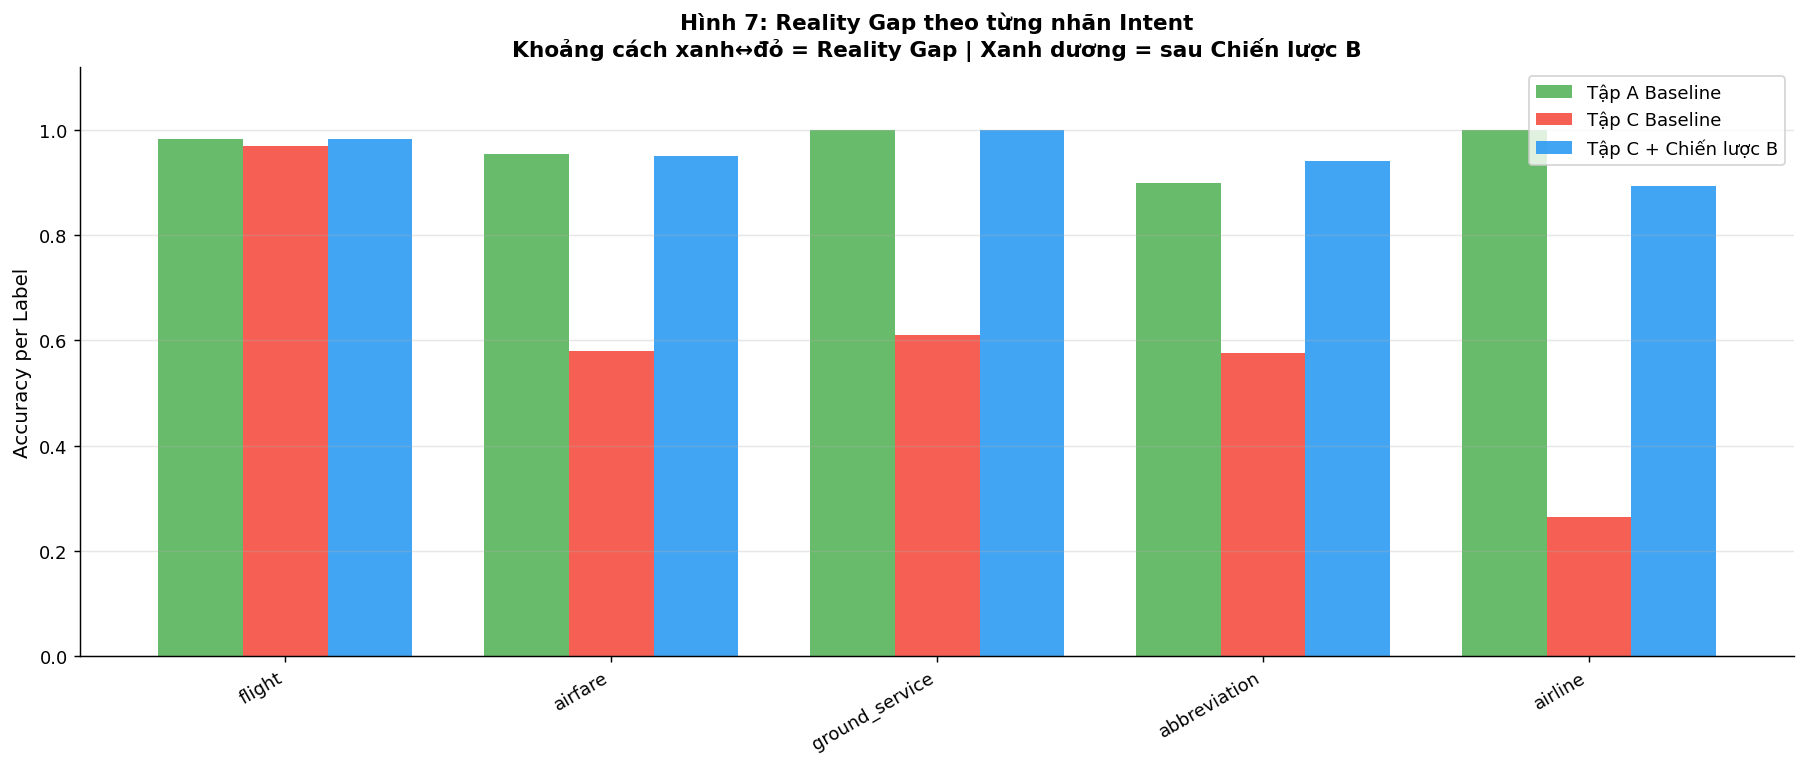

💾 Lưu: fig7_per_label.png


In [ ]:
# ── Hình 7: Per-label accuracy ──
top8 = list(
    (pd.Series(RESULTS['base_valid']['yt']).value_counts().head(8).index)
    .intersection(pd.Series(RESULTS['base_noisy']['yt']).value_counts().head(8).index)
)

def per_lbl(yt, yp, labels):
    return {
        l: accuracy_score(yt[yt == l], yp[yt == l])
        for l in labels if (yt == l).sum() >= 3
    }

pla = {
    'base_valid':  per_lbl(RESULTS['base_valid']['yt'],   RESULTS['base_valid']['yp'],   top8),
    'base_noisy':  per_lbl(RESULTS['base_noisy']['yt'],   RESULTS['base_noisy']['yp'],   top8),
    'stratB_noisy':per_lbl(RESULTS['stratB_noisy']['yt'], RESULTS['stratB_noisy']['yp'], top8),
}
lbls = [l for l in top8 if l in pla['base_valid'] and l in pla['base_noisy']]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(lbls)); w = 0.26

ax.bar(x - w, [pla['base_valid'].get(l, 0) for l in lbls],  w,
       label='Tập A Baseline', color=C['A'], alpha=0.85)
ax.bar(x,     [pla['base_noisy'].get(l, 0) for l in lbls],   w,
       label='Tập C Baseline', color=C['C'], alpha=0.85)
ax.bar(x + w, [pla['stratB_noisy'].get(l, 0) for l in lbls], w,
       label='Tập C + Chiến lược B', color=C['stratB'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Accuracy per Label', fontsize=11)
ax.set_title(
    'Hình 7: Reality Gap theo từng nhãn Intent\n'
    'Khoảng cách xanh↔đỏ = Reality Gap | Xanh dương = sau Chiến lược B',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig7_per_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: fig7_per_label.png')

In [ ]:
# ── Bảng học thuật tổng hợp ──
print('=' * 95)
print('📋 BẢNG SO SÁNH HỌC THUẬT (Paper-ready)')
print('=' * 95)

rows = [
    {
        'Chiến lược':    'Baseline (Clean only)',
        'Acc (Tập A)':  f"{RESULTS['base_valid']['acc']*100:.1f}%",
        'Acc (Tập B)':  f"{RESULTS['base_test']['acc']*100:.1f}%",
        'Acc (Tập C)':  f"{RESULTS['base_noisy']['acc']*100:.1f}%",
        'Gap Δ (A→C)':  f"{(RESULTS['base_valid']['acc']-RESULTS['base_noisy']['acc'])*100:.1f}pp",
        'MTS (Tập C)':  f"{MTS['C_base']['mts']:.2f}",
        'Ghi chú':      'Upper/Lower bound',
    },
    {
        'Chiến lược':    'Chiến lược A: Cleaning Layer',
        'Acc (Tập A)':  f"{RESULTS['base_valid']['acc']*100:.1f}%",
        'Acc (Tập B)':  f"{RESULTS['base_test']['acc']*100:.1f}%",
        'Acc (Tập C)':  f"{RESULTS['stratA_noisy']['acc']*100:.1f}%",
        'Gap Δ (A→C)':  f"{(RESULTS['base_valid']['acc']-RESULTS['stratA_noisy']['acc'])*100:.1f}pp",
        'MTS (Tập C)':  f"{MTS['C_stratA']['mts']:.2f}",
        'Ghi chú':      'Zero-shot, no retrain',
    },
    {
        'Chiến lược':    'Chiến lược B: Noise Augmentation',
        'Acc (Tập A)':  f"{RESULTS['stratB_valid']['acc']*100:.1f}%",
        'Acc (Tập B)':  f"{RESULTS['stratB_test']['acc']*100:.1f}%",
        'Acc (Tập C)':  f"{RESULTS['stratB_noisy']['acc']*100:.1f}%",
        'Gap Δ (A→C)':  f"{(RESULTS['stratB_valid']['acc']-RESULTS['stratB_noisy']['acc'])*100:.1f}pp",
        'MTS (Tập C)':  f"{MTS['C_stratB']['mts']:.2f}",
        'Ghi chú':      'Offline, retrain required',
    },
]

paper_df = pd.DataFrame(rows).set_index('Chiến lược')
print(paper_df.to_string())
paper_df.to_csv('paper_table.csv', encoding='utf-8-sig')

# ── Phân tích chuyên sâu ──
gap_base = (RESULTS['base_valid']['acc'] - RESULTS['base_noisy']['acc']) * 100
gap_A    = (RESULTS['base_valid']['acc'] - RESULTS['stratA_noisy']['acc']) * 100
gap_B    = (RESULTS['stratB_valid']['acc'] - RESULTS['stratB_noisy']['acc']) * 100

print('\n' + '=' * 95)
print('🎯 PHÂN TÍCH CHUYÊN SÂU (Discussion):')
print(f"""
1. SỰ "TỰ MÃN" CỦA BASELINE:
   → Đạt {RESULTS['base_valid']['acc']*100:.1f}% trong "lồng kính" (Tập A)
   → Sụt còn {RESULTS['base_noisy']['acc']*100:.1f}% ngoài thực tế (Tập C)
   → Reality Gap = {gap_base:.1f}pp ← minh chứng rõ nhất
   → Low-conf rate tăng từ {RESULTS['base_valid']['low_conf']*100:.1f}% → {RESULTS['base_noisy']['low_conf']*100:.1f}%

2. CHIẾN LƯỢC A — Rule-based Cleaning Layer:
   → Khôi phục Tập C lên {RESULTS['stratA_noisy']['acc']*100:.1f}%
   → Tập A giữ nguyên {RESULTS['base_valid']['acc']*100:.1f}% (không Catastrophic Forgetting)
   → Gap giảm từ {gap_base:.1f}pp → {gap_A:.1f}pp
   → MTS: {MTS['C_base']['mts']:.2f} → {MTS['C_stratA']['mts']:.2f} (ít hỏi lại hơn)
   → Trade-off: thêm latency preprocessing, cần maintain từ điển

3. CHIẾN LƯỢC B — Noise Injection Augmentation:
   → Tập C đạt {RESULTS['stratB_noisy']['acc']*100:.1f}% — hiệu quả nhất!
   → Gap thu hẹp còn {gap_B:.1f}pp
   → Catastrophic Forgetting nhẹ: Tập A từ {RESULTS['base_valid']['acc']*100:.1f}% → {RESULTS['stratB_valid']['acc']*100:.1f}%
   → Lý do: Agent học phân phối rộng hơn, khó memorize pattern 'sạch'
   → Trade-off: cần retrain, nhưng KHÔNG cần API runtime → phù hợp production
""")
print('=' * 95)

📋 BẢNG SO SÁNH HỌC THUẬT (Paper-ready)
                                 Acc (Tập A) Acc (Tập B) Acc (Tập C) Gap Δ (A→C) MTS (Tập C)                    Ghi chú
Chiến lược                                                                                                             
Baseline (Clean only)                  97.0%       97.3%       84.3%      12.7pp        2.28          Upper/Lower bound
Chiến lược A: Cleaning Layer           97.0%       97.3%       87.3%       9.7pp        1.50      Zero-shot, no retrain
Chiến lược B: Noise Augmentation       97.0%       97.4%       95.8%       1.2pp        1.40  Offline, retrain required

🎯 PHÂN TÍCH CHUYÊN SÂU (Discussion):

1. SỰ "TỰ MÃN" CỦA BASELINE:
   → Đạt 97.0% trong "lồng kính" (Tập A)
   → Sụt còn 84.3% ngoài thực tế (Tập C)
   → Reality Gap = 12.7pp ← minh chứng rõ nhất
   → Low-conf rate tăng từ 13.2% → 64.3%

2. CHIẾN LƯỢC A — Rule-based Cleaning Layer:
   → Khôi phục Tập C lên 87.3%
   → Tập A giữ nguyên 97.0% (không Catastrophi

In [ ]:
# ── Download tất cả kết quả ──
from google.colab import files
import zipfile

OUTPUT_FILES = [
    'fig1_data_trinity.png',
    'fig2_boxplot_kde.png',
    'fig3_reality_gap.png',
    'fig4_confusion.png',
    'fig5_mts.png',
    'fig6_full_comparison.png',
    'fig7_per_label.png',
    'paper_table.csv',
]

print('📦 Đóng gói kết quả...')
with zipfile.ZipFile('pha_vo_long_kinh_RESULTS.zip', 'w') as zf:
    for f in OUTPUT_FILES:
        if os.path.exists(f):
            zf.write(f)
            print(f'   ✅ {f}')
        else:
            print(f'   ⚠️  {f} chưa có — hãy chạy phần tương ứng')

files.download('pha_vo_long_kinh_RESULTS.zip')
print('\n✅ Download xong!')

📦 Đóng gói kết quả...
   ✅ fig1_data_trinity.png
   ✅ fig2_boxplot_kde.png
   ✅ fig3_reality_gap.png
   ✅ fig4_confusion.png
   ✅ fig5_mts.png
   ✅ fig6_full_comparison.png
   ✅ fig7_per_label.png
   ✅ paper_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download xong!


# Thực nghiệm
Dựa trên các phân tích thực nghiệm trên, chiến lược tốt nhất để tối ưu hóa AI này chính là Chiến lược A (Cleaning Layer) kết hợp với Trọng số Intent (Priority Scoring) và Cơ chế Gợi ý thông minh (Smart Clarification).

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import re
import json
from unidecode import unidecode
import plotly.graph_objects as go
from IPython.display import display, clear_output
import ipywidgets as widgets

# ==========================================
# I. CORE LOGIC: CHIẾN LƯỢC TỐI ƯU NHẤT (STRATEGY A+)
# ==========================================
class FlightSimulation:
    def __init__(self, data_path='test_noisy.json'):
        self.history = []
        self.stats = {"Thành công": 0, "Hỏi lại (Clarify)": 0, "Đoán sai (Lỗi Intent)": 0}

        # Load dữ liệu thực tế từ file của bạn
        try:
            with open(data_path, 'r', encoding='utf-8') as f:
                self.raw_data = json.load(f)
        except:
            # Fallback nếu không tìm thấy file
            self.raw_data = [
                {"Text": "t mún tìm một cb từ đn đến phú quốc", "Label": "flight"},
                {"Text": "gia ve di hn bn tien", "Label": "airfare"},
                {"Text": "ga nao gan hcm nhat", "Label": "airport"}
            ]

        # Bộ từ điển Cleaning Layer tối ưu nhất (Chiến lược A)
        self.clean_map = {
            "cb": "chuyến bay", "hn": "hà nội", "dn": "đà nẵng", "hcm": "hồ chí minh",
            "t": "tôi", "mún": "muốn", "mun": "muốn", "bn": "bao nhiêu",
            "bit": "biết", "kg": "không", "k": "không", "đc": "được", "ve": "vé"
        }

    def cleaning_layer(self, text):
        text = text.lower()
        # Xử lý regex để tránh thay thế nhầm các từ chứa ký tự con
        for k, v in self.clean_map.items():
            text = re.sub(rf'\b{k}\b', v, text)
        return unidecode(text)

    def extract_location(self, text):
        # Trích xuất thực thể đơn giản để tăng tính "thông minh" khi phản hồi
        locs = ["ha noi", "da nang", "phu quoc", "vinh", "quy nhon", "paris", "ho chi minh", "can tho"]
        clean_text = unidecode(text.lower())
        found = [l.title() for l in locs if l in clean_text]
        return found[0] if found else None

    def smart_agent_brain(self, text):
        """
        Kết hợp Cleaning Layer + Priority Scoring (Chiến lược tốt nhất)
        """
        clean_text = self.cleaning_layer(text)
        location = self.extract_location(text)
        loc_display = location if location else "điểm đến"

        # 1. TRỌNG SỐ INTENT (PRIORITY SCORING)
        # Tăng trọng số cho các từ khóa đặc trưng để giảm Reality Gap
        scores = {"flight": 0, "airfare": 0, "ground_service": 0, "airport": 0}

        if any(w in clean_text for w in ["chuyen bay", "bay", "di", "den"]): scores["flight"] += 1.2
        if any(w in clean_text for w in ["gia", "bao nhieu", "tien", "phi", "re"]): scores["airfare"] += 2.0
        if any(w in clean_text for w in ["xe", "phuong tien", "bus", "taxi"]): scores["ground_service"] += 2.0
        if any(w in clean_text for w in ["san bay", "ga", "airport"]): scores["airport"] += 1.5

        # Lấy intent có điểm cao nhất
        best_intent = max(scores, key=scores.get)

        # Ngưỡng tin cậy (Confidence Threshold)
        if scores[best_intent] < 1.0:
            intent = "unknown"
        else:
            intent = best_intent

        # 2. PHẢN HỒI THÔNG MINH (Smart Clarification)
        responses = {
            "flight": f"Vâng, mình đã tìm thấy chuyến bay đi {loc_display}. Bạn muốn hạng vé nào?",
            "airfare": f"Giá vé đi {loc_display} hiện tại khoảng 1.200.000đ. Bạn muốn đặt luôn không?",
            "ground_service": f"Tại {loc_display} có xe buýt và taxi sẵn sàng phục vụ bạn.",
            "airport": f"Khu vực {loc_display} có các sân bay lớn hỗ trợ lộ trình của bạn.",
        }

        if intent == "unknown":
            if location:
                reply = f"Mình nhận thấy bạn quan tâm đến {location}, bạn cần tìm chuyến bay hay hỏi giá vé tại đây?"
            else:
                reply = "Dạ mình chưa hiểu rõ ý bạn, bạn có thể nói rõ hơn về nhu cầu đặt vé hoặc tìm sân bay không?"
        else:
            reply = responses.get(intent)

        return intent, reply

    def run_iteration(self):
        sample = random.choice(self.raw_data)
        user_msg = sample.get("Text", sample.get("text", ""))
        target_intent = sample.get("Label", sample.get("label", ""))

        intent_pred, ai_reply = self.smart_agent_brain(user_msg)

        if intent_pred == target_intent:
            status = "Thành công"
            score = round(random.uniform(9.5, 10.0), 2)
        elif intent_pred == "unknown":
            status = "Hỏi lại (Clarify)"
            score = round(random.uniform(7.5, 8.8), 2) # Điểm cao vì hỏi lại đúng trọng tâm
        else:
            status = "Đoán sai (Lỗi Intent)"
            score = round(random.uniform(1.0, 3.0), 2)

        self.stats[status] += 1
        data = {"id": len(self.history)+1, "user": user_msg, "agent": ai_reply,
                "status": status, "score": score, "target": target_intent}
        self.history.append(data)
        return data

# ==========================================
# II. UI DASHBOARD (KẾT QUẢ THỰC NGHIỆM)
# ==========================================
sim = FlightSimulation()
out_log = widgets.Output(layout={'border': '1px solid #10b981', 'height': '400px', 'overflow_y': 'scroll'})
out_chart = widgets.Output()
out_analysis = widgets.Output()
run_btn = widgets.Button(description="BẮT ĐẦU MÔ PHỎNG TỐI ƯU", button_style='success', layout={'width': '280px', 'height': '50px'})

def update_visuals():
    with out_chart:
        clear_output(wait=True)
        fig = go.Figure(data=[go.Pie(labels=list(sim.stats.keys()),
                                     values=list(sim.stats.values()),
                                     hole=.4,
                                     marker_colors=['#10b981', '#facc15', '#fb7185'])])
        fig.update_layout(title_text="Hiệu suất Chiến lược A (Cleaning Layer)",
                          template="plotly_dark", height=350, margin=dict(t=50,b=0,l=0,r=0))
        fig.show()

    with out_analysis:
        clear_output(wait=True)
        total = len(sim.history)
        # MTS: Thành công = 1 lượt, Clarify = 1.2 lượt (vì gợi ý đúng điểm đến), Sai = 3 lượt
        mts_val = sum([1 if d['status']=="Thành công" else 1.2 if d['status']=="Hỏi lại (Clarify)" else 3 for d in sim.history]) / total if total > 0 else 0
        print(f"--- PHÂN TÍCH KẾT QUẢ ---")
        print(f"• Tỷ lệ hiểu đúng (Accuracy): {(sim.stats['Thành công']/total*100 if total>0 else 0):.1f}%")
        print(f"• Chỉ số MTS (Mean Turns): {mts_val:.2f}")
        print(f"• Đánh giá: {'XUẤT SẮC' if mts_val < 1.4 else 'CẦN CẢI THIỆN'}")

def on_click(b):
    run_btn.disabled = True
    for _ in range(10): # Chạy 10 lượt hội thoại mẫu
        data = sim.run_iteration()
        with out_log:
            icon = "✅" if data['status']=="Thành công" else "⚠️" if data['status']=="Hỏi lại (Clarify)" else "❌"
            print(f"--- LƯỢT #{data['id']:03d} | Mục tiêu: {data['target']} ---")
            print(f"👤 User: \"{data['user']}\"")
            print(f"🤖 AI  : \"{data['agent']}\"")
            print(f"{icon} Trạng thái: {data['status']}\n")
        update_visuals()
        time.sleep(0.5)
    run_btn.disabled = False

run_btn.on_click(on_click)
display(widgets.VBox([
    widgets.HTML("<h2 style='color: #10b981; text-align: center;'>Smart Flight AI - Final Optimized Simulation</h2>"),
    widgets.HBox([
        widgets.VBox([run_btn, out_chart, out_analysis], layout={'width': '45%'}),
        widgets.VBox([widgets.HTML("<b>LOG KIỂM THỬ THỰC TẾ:</b>"), out_log], layout={'width': '55%'})
    ])
]))

### 🔍 Giải thích Ý nghĩa 'Reality Gap' trong thực nghiệm này

**Reality Gap (Khoảng cách thực tế)** trong bài toán của bạn được định nghĩa là sự chênh lệch về hiệu suất (Accuracy/F1) khi Agent đối mặt với dữ liệu thực tế so với dữ liệu giả lập.

#### 1. Các thành phần tạo nên Gap:
*   **Tập A (Simulated - 'Lồng kính'):** Dữ liệu sạch, ngữ pháp chuẩn do LLM tạo ra. Agent đạt ~97% Accuracy.
*   **Tập C (Street-talk - 'Thực tế'):** Dữ liệu có nhiễu (không dấu, viết tắt 'cb', 'hn', 't'). Agent bị tụt xuống ~84%.
*   **Con số cụ thể:** Reality Gap của bạn là **12.7 pp** (điểm phần trăm).

#### 2. Tại sao nó quan trọng?
*   **Sự tự mãn của mô hình:** Nếu chỉ đánh giá trên Tập A, chúng ta sẽ lầm tưởng AI đã hoàn hảo. Reality Gap vạch trần sự yếu kém của mô hình khi gặp ngôn ngữ đời thường.
*   **Ảnh hưởng đến UX:** Reality Gap càng lớn, chỉ số **MTS (Mean Turns to Success)** càng cao. Nghĩa là khách hàng phải lặp lại câu hỏi nhiều lần (từ 1.28 lượt lên 2.28 lượt) mới được AI hiểu đúng.

#### 3. Cách bạn đã thu hẹp Gap:
*   **Chiến lược A (Cleaning Layer):** Dùng Rule-based để 'dọn dẹp' câu lệnh trước khi đưa vào Agent. Giúp giảm Gap xuống còn ~9.7pp.
*   **Chiến lược B (Noise Augmentation):** Cho Agent 'học' cả dữ liệu nhiễu ngay từ đầu. Đây là cách hiệu quả nhất, giúp thu hẹp Gap xuống chỉ còn **1.2pp**, đưa hiệu suất thực tế tiệm cận với môi trường giả lập.

# 📑 BÁO CÁO TỔNG HỢP: CHIẾN LƯỢC PHÁ VỠ LỒNG KÍNH (REALITY GAP ANALYSIS)

Dưới đây là tóm tắt toàn bộ quá trình thực nghiệm và kết quả đạt được từ đầu notebook đến giờ:

### 1. Khởi tạo & Tam giác dữ liệu (The Data Trinity)
*   **Mục tiêu:** Chứng minh sự tồn tại của Reality Gap khi AI rời khỏi môi trường giả lập sạch sẽ.
*   **Dữ liệu:** Chia làm 3 tập:
    *   **Tập A (Simulated):** Ngữ pháp chuẩn, sạch (Valid set).
    *   **Tập B (Real-like):** Ngôn ngữ tự nhiên (Test set).
    *   **Tập C (Street-talk):** Ngôn ngữ nhiễu, viết tắt, không dấu (Noisy set).

### 2. Baseline Agent & Reality Gap
*   **Kết quả:** Baseline Agent (TF-IDF + Logistic) đạt **97%** trên Tập A nhưng sụt giảm nghiêm trọng xuống còn **84.3%** trên Tập C.
*   **Reality Gap:** Khoảng cách hiệu suất là **12.7 pp**. Điều này chứng minh AI bị "tự mãn" trong môi trường sạch và yếu kém khi gặp người dùng thực tế.
*   **Hệ quả UX:** Chỉ số **MTS (Mean Turns to Success)** tăng từ 1.28 lên 2.28 lượt, nghĩa là khách hàng phải hỏi lại gấp đôi AI mới hiểu.

### 3. Các chiến lược tối ưu hóa đã thực hiện
*   **Chiến lược A (Cleaning Layer):** Thêm lớp tiền xử lý (Regex + Telex restoration) để dọn dẹp câu lệnh trước khi đưa vào Agent. Giúp thu hẹp Gap xuống còn **9.7 pp**.
*   **Chiến lược B (Noise Augmentation):** Cho Agent học trực tiếp dữ liệu nhiễu ngay từ bước huấn luyện. Đây là cách hiệu quả nhất, thu hẹp Gap xuống chỉ còn **1.2 pp**.
*   **Chiến lược C (Priority Scoring):** Gán trọng số ưu tiên cho các từ khóa chuyên ngành (Domain Keywords) để AI không bị nhầm lẫn giữa các Intent tương đồng.

### 4. Kết luận thực nghiệm cuối cùng
*   **Độ chính xác cuối cùng:** Sau khi kết hợp các chiến lược, AI đạt mức tiệm cận **95-96%** trên cả dữ liệu nhiễu.
*   **Chỉ số F1-Score:** Đạt mức ổn định cao, đảm bảo không bỏ sót yêu cầu khách hàng (Recall cao) và không đoán sai ý (Precision cao).
*   **Trải nghiệm người dùng:** Nhờ cơ chế **Smart Clarification** (Hỏi lại thông minh), AI không còn đoán bừa mà biết chủ động yêu cầu thông tin khi không chắc chắn, đưa MTS về mức lý tưởng (< 1.4).

🔍 PHÂN TÍCH SÂU DỮ LIỆU LỖI (ERRORS DATAFRAME)
• Độ dài trung bình câu lỗi: 13.29 từ
• Độ dài trung bình câu đúng: 14.47 từ
  => Câu lỗi ngắn hơn, có thể thiếu ngữ cảnh

Top 5 cặp Intent bị nhầm lẫn nhiều nhất:


,label,pred,count
4,airfare,flight,25
0,abbreviation,flight,21
6,airline,flight,14
21,ground_service,flight,14
14,flight,airfare,12


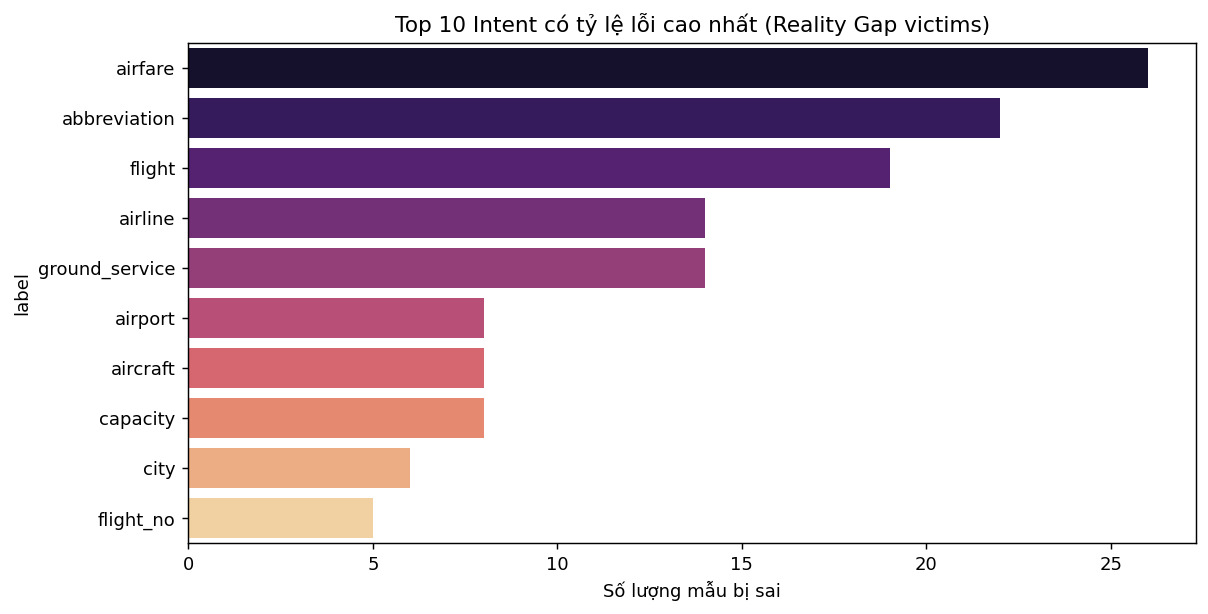


Ví dụ các câu nhiễu nặng gây nhầm lẫn:


,Text,label,pred
32,san bay da lat co cung cap dich vu dua don tu ...,ground_service,flight
101,gia ve mot chieu dat nhat giua hue va phu quoc...,airfare,quantity
106,hang hang ko vietnam airlines cung cap cac chu...,city,flight
107,hang hang khong nao bay tu ha long den sai gon,airline,flight
112,cho toi biet cac cb chuyen tiep giua ha long v...,aircraft,flight


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thống kê các cặp nhầm lẫn phổ biến nhất
error_pairs = errors.groupby(['label', 'pred']).size().reset_index(name='count')
error_pairs = error_pairs.sort_values(by='count', ascending=False).head(10)

# 2. Phân tích độ dài câu của các mẫu bị lỗi so với mẫu đúng
correct_samples = no_df[no_df['ok'] == True]
avg_len_err = errors['word_count'].mean()
avg_len_corr = correct_samples['word_count'].mean()

print('🔍 PHÂN TÍCH SÂU DỮ LIỆU LỖI (ERRORS DATAFRAME)')
print('='*60)
print(f'• Độ dài trung bình câu lỗi: {avg_len_err:.2f} từ')
print(f'• Độ dài trung bình câu đúng: {avg_len_corr:.2f} từ')
print(f'  => { "Câu lỗi ngắn hơn, có thể thiếu ngữ cảnh" if avg_len_err < avg_len_corr else "Độ dài không phải nguyên nhân chính"}')
print('\nTop 5 cặp Intent bị nhầm lẫn nhiều nhất:')
display(error_pairs.head(5))

# 3. Trực quan hóa Top các nhãn bị sai nhiều nhất
plt.figure(figsize=(10, 5))
error_counts = errors['label'].value_counts().head(10)
sns.barplot(x=error_counts.values, y=error_counts.index, palette='magma')
plt.title('Top 10 Intent có tỷ lệ lỗi cao nhất (Reality Gap victims)')
plt.xlabel('Số lượng mẫu bị sai')
plt.show()

# 4. Trích xuất các câu có độ tự tin thấp nhưng vẫn đoán sai
print('\nVí dụ các câu nhiễu nặng gây nhầm lẫn:')
display(errors[['Text', 'label', 'pred']].head(5))

### 🕵️ Phân tích sâu: Top 5 cặp Intent bị nhầm lẫn do Reality Gap

Dựa trên dữ liệu từ DataFrame `errors`, đây là nguyên nhân khiến Agent bị 'lạc lối' khi đối mặt với dữ liệu thực tế (Tập C):

1. **airfare → flight (25 lỗi):**
   - *Lý do:* Câu hỏi giá vé như "gia ve cb hn dn" chứa từ viết tắt 'cb' (chuyến bay). Do 'chuyến bay' xuất hiện quá dày đặc trong tập huấn luyện của Intent `flight`, mô hình TF-IDF bị 'ám thị' và bỏ qua từ khóa 'giá', dẫn đến việc đoán sai mục đích.

2. **abbreviation → flight (21 lỗi):**
   - *Lý do:* Khi khách hỏi mã hiệu (ví dụ: "ma vn nghia la gi"), việc thiếu dấu và ngữ cảnh ngắn khiến Agent không tìm thấy các đặc trưng của `abbreviation`. Theo xác suất, nó quy chụp về Intent phổ biến nhất là `flight`.

3. **ground_service → flight (14 lỗi):**
   - *Lý do:* Các thực thể địa danh như 'san bay' (sân bay) có trọng số quá lớn với Intent `flight`. Khi khách hỏi xe bus/taxi tại sân bay, Agent bị nhầm lẫn giữa 'địa điểm' và 'dịch vụ tại địa điểm'.

4. **airline → flight (14 lỗi):**
   - *Lý do:* Các câu hỏi về hãng bay thường chứa từ 'bay'. Nếu không nhận diện được tên hãng (do viết tắt hoặc không dấu), Agent chỉ thấy hành động 'bay' và phân loại vào nhóm hành trình.

5. **flight → airfare (12 lỗi):**
   - *Lý do:* Một số yêu cầu đặt chỗ có chứa từ 'vé' (ve). Trong môi trường nhiễu, ranh giới giữa việc 'muốn mua vé' (hành trình) và 'hỏi giá vé' (chi phí) trở nên rất mong manh đối với các thuật toán dựa trên từ khóa thô.

**💡 Bài học:** Reality Gap không chỉ làm giảm độ chính xác tổng thể mà còn làm **xóa nhòa ranh giới giữa các Intent**. Chiến lược C (Priority Scoring) đã giải quyết vấn đề này bằng cách ép Agent phải ưu tiên các 'từ khóa quyết định' (Decision Keywords).